# Deng control-volume reconstruction for the rectangular nonconforming MMS (P0 multiplier)

This notebook solves the same full-diagonal MMS fracture problem as the nonconforming triangular notebook, but uses a rectangular/quadrilateral unit-square bulk mesh. The physical fracture remains `(0, 0) -> (1, 1)`, so it is handled by the nonconforming point-trace LCG approach with independent 1D fracture-pressure and multiplier meshes.

The rectangular bulk mesh follows the reference notebook `LCG_Deng_flux_reconstruction_KoppelMartin_case1_rect_nonconforming_no_fenicsx_ii.ipynb`: it is created directly with DOLFINx as a quadrilateral unit-square mesh, so there is no `.msh` file to regenerate.

The Deng reconstruction below uses tensor-product control volumes, so the same code handles Q1 and Q2 rectangular pressure elements.


In [69]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import math
import time
import pathlib
import basix
import basix.ufl
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem
import ufl

# Rectangular Deng reconstruction supports Q1/Q2 pressure elements.
order = 1
lambda_order = 0
PRESSURE_ORDER = order
MULTIPLIER_ORDER = lambda_order
FEM_ORDER = PRESSURE_ORDER
Gamma_tag = 2  # compatibility alias; the rectangular mesh has no Gamma facets.

# Independent 1D mesh sizes. The fracture pressure mesh uses h_gamma ~= h/2,
# while the P0 multiplier is coarser to avoid the nonconforming inf-sup trouble.
FRACTURE_PRESSURE_LC_FACTOR = 0.5
LAMBDA_COARSEN = 3.0
MULTIPLIER_LC_FACTOR = LAMBDA_COARSEN

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
# Also run the Deng control-volume reconstruction + LCE/CV diagnostics inside the
# convergence study.  Set False for a fast CG-solve-only convergence run
# (matches the lightweight Section 0 of the nonconforming PINN MMS notebook).
RUN_DENG_RECONSTRUCTION = True
CONV_REFS = [2,3,4,5, 6,7]
CONV_TIP_FRAC = 0.05
CONV_PLOT = True

CASES = [
    {"name": "rect_Q1_P0", "order": 1, "lambda_order": 0},
    {"name": "rect_Q2_P0", "order": 2, "lambda_order": 0},
    {"name": "rect_Q2_P1", "order": 2, "lambda_order": 1}
]
RESULTS_DIR = pathlib.Path("deng_convergence_results/rect_nonconforming_p0")

# Main comparison run.
REF_DEMO = 6

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = CONV_TIP_FRAC

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
FRAC_A = np.array([x_start, y_start], dtype=float)
FRAC_B = np.array([x_end, y_end], dtype=float)
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

# Manual point-trace assembly is serial.  COMM_SELF also keeps the notebook safe
# when opened from a normal single-kernel Jupyter session.
comm = MPI.COMM_SELF
rank = comm.rank

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [70]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def q_exact_xy(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)


def r_exact_xy(x, y):
    return normal_np[0] * (x - FRAC_A[0]) + normal_np[1] * (y - FRAC_A[1])


def p_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    return q + ALPHA * np.abs(r_exact_xy(x, y)) * q


def p_gamma_exact_xy(x, y):
    return q_exact_xy(x, y)


def lambda_exact_xy(x, y):
    return -2.0 * ALPHA * q_exact_xy(x, y)



def grad_q_exact_xy(x, y):
    return np.column_stack([
        np.pi * np.cos(np.pi * x) * np.sin(np.pi * y),
        np.pi * np.sin(np.pi * x) * np.cos(np.pi * y),
    ])


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    grad_q = grad_q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return grad_q + ALPHA * (
        sign_r[:, None] * normal_np[None, :] * q[:, None]
        + np.abs(r)[:, None] * grad_q
    )


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)


def exact_dp_gamma_ds(s):
    pts = real_points_np(s)
    grad_q = grad_q_exact_xy(pts[:, 0], pts[:, 1])
    return grad_q @ tau_np


def f_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np[0] * np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
        + normal_np[1] * np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    )
    return K_M_VALUE * (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )


def f_gamma_exact_xy(x, y):
    qg = q_exact_xy(x, y)
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np[0] * tau_np[1]
        * np.cos(np.pi * x) * np.cos(np.pi * y)
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_xy(x, y)


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    except (TypeError, AttributeError, IndexError):
        gamma_mesh = mesh.create_mesh(comm, cells, nodes, coord_el)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells), s_nodes


def make_fracture_meshes(h):
    h_gamma_target = FRACTURE_PRESSURE_LC_FACTOR * h
    h_lambda_target = MULTIPLIER_LC_FACTOR * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    n_lambda = max(1, int(np.ceil(L_gamma / h_lambda_target)))
    s_gamma = np.linspace(0.0, L_gamma, n_gamma + 1)
    s_lambda = np.linspace(0.0, L_gamma, n_lambda + 1)
    gamma, h_gamma, n_gamma, _ = make_line_mesh_from_s_nodes(s_gamma)
    gamma_l, h_lambda, n_lambda, _ = make_line_mesh_from_s_nodes(s_lambda)
    return gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda


def make_nonconforming_meshes(ref):
    # Use ref directly so REF_DEMO=6 gives h=1/64, matching the opposite-diagonal mesh.
    n_bulk = 2 ** ref
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda = make_fracture_meshes(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def gauss_interval(n):
    x, w = np.polynomial.legendre.leggauss(int(n))
    return 0.5 * (x + 1.0), 0.5 * w


_GB, _WB = gauss_interval(8)
_GL, _WL = gauss_interval(10)


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_GB):
        for j, eta in enumerate(_GB):
            pts.append([xi, eta])
            weights.append(_WB[i] * _WB[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


# Compatibility callables used by the copied Deng reporting cells.
def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def ff_callable(x):
    return f_gamma_exact_xy(x[0], x[1])


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


In [71]:
def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders

    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_xy = dof_coords[dofs]
        nodes_per_dir = int(round(len(dofs) ** 0.5))
        assert nodes_per_dir * nodes_per_dir == len(dofs), "tensor-product Qk cell expected"
        assert nodes_per_dir in (2, 3), "equispaced node assumption only valid for Q1/Q2"
        xi_nodes = np.linspace(0.0, 1.0, nodes_per_dir)
        eta_nodes = np.linspace(0.0, 1.0, nodes_per_dir)
        xi_raw = np.clip((dof_xy[:, 0] - x0) / (x1 - x0), 0.0, 1.0)
        eta_raw = np.clip((dof_xy[:, 1] - y0) / (y1 - y0), 0.0, 1.0)
        dof_xi_idx = np.argmin(np.abs(xi_raw[:, None] - xi_nodes[None, :]), axis=1)
        dof_eta_idx = np.argmin(np.abs(eta_raw[:, None] - eta_nodes[None, :]), axis=1)
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_xy,
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "xi_nodes": xi_nodes,
            "eta_nodes": eta_nodes,
            "dof_xi_idx": dof_xi_idx,
            "dof_eta_idx": dof_eta_idx,
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1.0e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def quad_lagrange_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts[:, 0] - cell["x0"]) / cell["hx"]
    eta = (pts[:, 1] - cell["y0"]) / cell["hy"]
    Lx, dLx = lagrange_1d_values_and_derivatives(cell["xi_nodes"], xi)
    Ly, dLy = lagrange_1d_values_and_derivatives(cell["eta_nodes"], eta)
    nd = len(cell["dofs"])
    vals = np.zeros((pts.shape[0], nd), dtype=float)
    grads = np.zeros((pts.shape[0], nd, 2), dtype=float)
    for a in range(nd):
        ix = cell["dof_xi_idx"][a]
        iy = cell["dof_eta_idx"][a]
        vals[:, a] = Lx[:, ix] * Ly[:, iy]
        grads[:, a, 0] = (dLx[:, ix] / cell["hx"]) * Ly[:, iy]
        grads[:, a, 1] = Lx[:, ix] * (dLy[:, iy] / cell["hy"])
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1.0e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


def build_line_space_data(domain, V):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    geom_s = s_coord_np(domain.geometry.x[:, :2])
    dof_coords = V.tabulate_dof_coordinates()[:, :2]
    dof_s_all = s_coord_np(dof_coords)
    cells = []
    s_nodes = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s0, s1 = np.sort(geom_s[verts])
        dofs = np.asarray(V.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_s = dof_s_all[dofs]
        ell = float(s1 - s0)
        nodes = np.unique(np.round((dof_s - s0) / ell, 14))
        dof_node_idx = np.searchsorted(nodes, np.round((dof_s - s0) / ell, 14))
        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "s0": float(s0),
            "s1": float(s1),
            "ell": ell,
            "nodes": nodes,
            "dof_node_idx": dof_node_idx,
        })
        s_nodes.extend([float(s0), float(s1)])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    cells = [cells[i] for i in np.argsort([c["s0"] for c in cells])]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_line_cell_s(s, line_data, tol=1.0e-12):
    cells = line_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def line_values_derivatives_on_cell(cell, s):
    s = np.asarray(s, dtype=float).reshape(-1)
    xi = (s - cell["s0"]) / cell["ell"]
    L, dL = lagrange_1d_values_and_derivatives(cell["nodes"], xi)
    nd = len(cell["dofs"])
    vals = np.zeros((s.size, nd), dtype=float)
    ders = np.zeros((s.size, nd), dtype=float)
    for a in range(nd):
        ia = cell["dof_node_idx"][a]
        vals[:, a] = L[:, ia]
        ders[:, a] = dL[:, ia] / cell["ell"]
    return vals, ders


def s_breakpoints(s0, s1, s_nodes, tol=1.0e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    t = b - a
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm > 0.0 else chosen


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm > 0.0 else chosen


def point_in_convex_polygon(pt, poly, tol=1.0e-12):
    pt = np.asarray(pt, dtype=float)
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1.0e-12):
    edge_a = np.asarray(edge_a, dtype=float)
    edge_b = np.asarray(edge_b, dtype=float)
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1.0e-11):
    poly = order_polygon_vertices(np.asarray(poly, dtype=float))
    span = np.ptp(poly, axis=0)
    if abs(polygon_signed_area(poly)) <= tol * tol or np.min(span) <= tol:
        return []
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1.0e-10):
            intervals.append((float(s0), float(s1)))
    return intervals


def segment_key(a, b, decimals=12):
    ka = tuple(np.round(np.asarray(a, dtype=float), decimals))
    kb = tuple(np.round(np.asarray(b, dtype=float), decimals))
    return tuple(sorted((ka, kb)))


def assemble_bulk_blocks(A, b, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        fe = area * np.einsum("q,q,qi->i", qw, f_m_exact_xy(x_phys[:, 0], x_phys[:, 1]), vals)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(cell["dofs"], fe, addv=PETSc.InsertMode.ADD_VALUES)


def assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_line_space_data(gamma, V_f)
    multiplier_data = build_line_space_data(gamma_l, V_l)

    # Fracture pressure equation: int K_f dp_f/ds dpsi/ds + int lambda psi = int f_f psi.
    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        weight = cell["ell"] * _WL
        Kloc = K_F_VALUE * np.einsum("q,qi,qj->ij", weight, dpsi, dpsi)
        floc = np.einsum("q,q,qi->i", weight, f_gamma_exact_xy(x_q[:, 0], x_q[:, 1]), psi)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(off_f + fdofs, floc, addv=PETSc.InsertMode.ADD_VALUES)

    for lcell in multiplier_data["cells"]:
        ldofs = lcell["dofs"]
        s0, s1 = lcell["s0"], lcell["s1"]

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, c in zip(pbreaks[:-1], pbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            pcell = locate_line_cell_s(0.5 * (a + c), pressure_data)
            fdofs = pcell["dofs"]
            s_q = a + (c - a) * _GL
            psi = line_values_derivatives_on_cell(pcell, s_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(off_f + fdofs, off_l + ldofs, np.einsum("q,qi,qj->ij", weight, psi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, off_f + fdofs, -np.einsum("q,qi,qj->ij", weight, mu, psi), addv=PETSc.InsertMode.ADD_VALUES)

        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1.0e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            r_q = r0 + (r1 - r0) * _GL
            s_q = s0 + (s1 - s0) * r_q
            x_q = xa[None, :] + r_q[:, None] * seg[None, :]
            phi = quad_lagrange_values_grads_on_cell(bulk_cell, x_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (s1 - s0) * (r1 - r0) * _WL
            A.setValues(mdofs, off_l + ldofs, -np.einsum("q,qi,qj->ij", weight, phi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, mdofs, np.einsum("q,qi,qj->ij", weight, mu, phi), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, _ = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1.0e-12

    bnd_m = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol)
        | np.isclose(coords_m[:, 0], 1.0, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol)
        | np.isclose(coords_m[:, 1], 1.0, atol=tol)
    )[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")

    bc_idx = np.concatenate([off_m + bnd_m, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        p_m_exact_xy(coords_m[bnd_m, 0], coords_m[bnd_m, 1]),
        p_gamma_exact_xy(coords_f[tip_a, 0], coords_f[tip_a, 1]),
        p_gamma_exact_xy(coords_f[tip_b, 0], coords_f[tip_b, 1]),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC):
    p_m = sol["p_m"]
    p_f = sol["p_f"]
    lmbd = sol["lmbd"]
    bulk_data = sol["bulk_data"]
    pressure_data = build_line_space_data(sol["gamma"], sol["V_f"])
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    qp, qw = quad_points_weights()

    err_pm_sq = 0.0
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals = quad_lagrange_values_grads_on_cell(cell, x_phys)[0]
        ph = vals @ p_m.x.array[cell["dofs"]]
        ex = p_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
        err_pm_sq += cell["hx"] * cell["hy"] * float(np.dot(qw, (ph - ex) ** 2))

    err_pf_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi = line_values_derivatives_on_cell(cell, s_q)[0]
        ph = psi @ p_f.x.array[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        err_pf_sq += float(np.dot(cell["ell"] * _WL, (ph - ex) ** 2))

    err_lam_sq = 0.0
    err_lam_int_sq = 0.0
    for cell in multiplier_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        mu = line_values_derivatives_on_cell(cell, s_q)[0]
        lh = mu @ lmbd.x.array[cell["dofs"]]
        ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
        diff2 = (lh - ex) ** 2
        weight = cell["ell"] * _WL
        err_lam_sq += float(np.dot(weight, diff2))
        t_q = s_q / L_gamma
        mask = (t_q >= tip_frac) & (t_q <= 1.0 - tip_frac)
        err_lam_int_sq += float(np.dot(weight * mask.astype(float), diff2))

    return {
        "err_pm": np.sqrt(max(err_pm_sq, 0.0)),
        "err_pf": np.sqrt(max(err_pf_sq, 0.0)),
        "err_lam": np.sqrt(max(err_lam_sq, 0.0)),
        "err_lam_int": np.sqrt(max(err_lam_int_sq, 0.0)),
    }


def solve_lcg_nonconforming_mms_2d(ref, pressure_order=PRESSURE_ORDER, multiplier_order=MULTIPLIER_ORDER, return_solution=False, verbose=False):
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", pressure_order))
    V_f = fem.functionspace(gamma, ("Lagrange", pressure_order))
    V_l = fem.functionspace(gamma_l, ("DG", 0)) if multiplier_order == 0 else fem.functionspace(gamma_l, ("Lagrange", multiplier_order))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=240, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    b = PETSc.Vec().createSeq(n_total, comm=comm)
    b.set(0.0)

    assemble_bulk_blocks(A, b, bulk_data)
    assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()
    b.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"mms2d_ref{ref}_p{pressure_order}_l{multiplier_order}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    sol = {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_pm": int(n_m),
        "ndof_pf": int(n_f),
        "ndof_lam": int(n_l),
        "ndof_total": int(n_total),
        "pressure_order": int(pressure_order),
        "multiplier_order": int(multiplier_order),
        "factor_solver": factor_solver,
    }
    sol.update(compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC))

    if verbose and rank == 0:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda={n_l}, total={n_total}")

    if return_solution:
        return sol
    return {k: sol[k] for k in [
        "ref", "h", "h_gamma", "h_lambda", "n_bulk", "n_gamma", "n_lambda",
        "ndof_pm", "ndof_pf", "ndof_lam", "ndof_total", "pressure_order", "multiplier_order",
        "err_pm", "err_pf", "err_lam", "err_lam_int", "factor_solver",
    ]}



def solve_lcg_mms(ref, verbose=False):
    if int(order) not in (1, 2):
        raise NotImplementedError("Rectangular Deng reconstruction supports Q1/Q2 pressure elements; set order = 1 or 2.")
    sol = solve_lcg_nonconforming_mms_2d(
        ref,
        pressure_order=int(order),
        multiplier_order=int(lambda_order),
        return_solution=True,
        verbose=verbose,
    )
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    s_lambda = multiplier_data["s_nodes"]

    k_m = fem.Constant(sol["omega"], PETSc.ScalarType(K_M_VALUE))
    f_m = fem.Function(sol["V_m"], name="f_m")
    f_m.interpolate(f_callable)

    ctx = dict(sol)
    ctx.update({
        "V": sol["V_m"],
        "p_sol": sol["p_m"],
        "k_m": k_m,
        "f_m": f_m,
        "Gamma_tag": Gamma_tag,
        "gamma_entities": np.array([], dtype=np.int32),
        "gamma_to_omega": None,
        "gamma_vertex_to_omega": None,
        "cell_markers": None,
        "facet_markers": None,
        "all_dofs": sol["bc_idx"][sol["bc_idx"] < sol["ndof_pm"]].astype(np.int32),
        "iterations": 1,
        "dofs": int(sol["ndof_pm"]),
        "dofs_lambda": int(sol["ndof_lam"]),
        "dofs_total": int(sol["ndof_total"]),
        "lambda_space": "DG0" if int(lambda_order) == 0 else f"P{int(lambda_order)}",
        "lambda_s_nodes": s_lambda,
        "lambda_t_nodes": real_points_np(s_lambda)[:, 0],
        "h_lambda_arc": float(sol["h_lambda"]),
        "lambda_balance_sign": 1.0,
        "err_pm": float(sol["err_pm"]),
        "err_pf": float(sol["err_pf"]),
        "err_lam": float(sol["err_lam"]),
        "mesh_file": "dolfinx.create_unit_square(..., cell_type=mesh.CellType.quadrilateral)",
        "mesh_source": "DOLFINx quadrilateral unit-square mesh",
        "multiplier_data": multiplier_data,
    })
    return ctx


In [72]:
# ============================================================
# Rectangular geometry and field-evaluation helpers
# ============================================================
def extend_line_to_bbox(a, tau, bbox, tol=1.0e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in (xmin, xmax):
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(float(t))
    if abs(tau[1]) > tol:
        for yval in (ymin, ymax):
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(float(t))
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)

def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        try:
            omega.topology.create_connectivity(*pair)
        except Exception:
            pass

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(ctx.get("h", np.sqrt(np.mean(cell_areas))))

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = FRAC_A + t_min * tau_np
    ghost_end = FRAC_A + t_max * tau_np

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1.0e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
        if t_max - L_gamma > 1.0e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": {},
        "gamma_facet_set": set(),
        "FRAC_A": FRAC_A.copy(),
        "FRAC_B": FRAC_B.copy(),
        "tau_np": tau_np.copy(),
        "normal_np": normal_np.copy(),
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
    }


In [73]:
# ============================================================
# Rectangular multiplier/source helpers
# ============================================================
# ============================================================
# Tensor-product rectangular Deng reconstruction for the nonconforming MMS
# ============================================================
def convergence_rate(errors, hs):
    errors = np.asarray(errors, dtype=float)
    hs = np.asarray(hs, dtype=float)
    rates = [np.nan]
    for e0, e1, h0, h1 in zip(errors[:-1], errors[1:], hs[:-1], hs[1:]):
        if e0 > 0.0 and e1 > 0.0 and h0 > 0.0 and h1 > 0.0 and h0 != h1:
            rates.append(float(np.log(e0 / e1) / np.log(h0 / h1)))
        else:
            rates.append(np.nan)
    return rates


def fmt_rate(value):
    return "  -  " if not np.isfinite(value) else f"{value:5.2f}"


def residual_stats(values, ids=None):
    vals = np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float)
    if vals.size == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    vals = np.abs(vals)
    return {"n": int(vals.size), "mean": float(np.mean(vals)), "median": float(np.median(vals)), "max": float(np.max(vals))}


def rect_boundary_vertex_mask(rect, tol=1.0e-12):
    xy = rect["vertices_xy"]
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )


def physical_edge_defs(cell):
    cached = cell.get("physical_edges")
    if cached is not None:
        return cached
    x0, x1 = float(cell["x0"]), float(cell["x1"])
    y0, y1 = float(cell["y0"]), float(cell["y1"])
    edges = [
        ("bottom", np.array([x0, y0], dtype=float), np.array([x1, y0], dtype=float), np.array([0.0, -1.0], dtype=float)),
        ("right",  np.array([x1, y0], dtype=float), np.array([x1, y1], dtype=float), np.array([1.0, 0.0], dtype=float)),
        ("top",    np.array([x0, y1], dtype=float), np.array([x1, y1], dtype=float), np.array([0.0, 1.0], dtype=float)),
        ("left",   np.array([x0, y0], dtype=float), np.array([x0, y1], dtype=float), np.array([-1.0, 0.0], dtype=float)),
    ]
    return [
        {"side": side, "a": a, "b": b, "normal": n, "key": segment_key(a, b)}
        for side, a, b, n in edges
    ]


def physical_edge_map(cell):
    cached = cell.get("physical_edge_map")
    if cached is not None:
        return cached
    return {edge["side"]: edge for edge in physical_edge_defs(cell)}


def prepare_deng_rect_data(sol):
    pressure_order = int(sol["pressure_order"])
    if pressure_order not in (1, 2):
        raise NotImplementedError(
            "The rectangular Deng reconstruction is implemented for tensor-product Q1/Q2 pressure elements."
        )

    vertex_key_to_id = {}
    vertices_xy = []
    cells = []
    pvals = sol["p_m"].x.array

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, base in enumerate(sol["bulk_data"]["cells"]):
        base_dofs = np.asarray(base["dofs"], dtype=np.int32)
        base_xy = np.asarray(base["dof_xy"], dtype=float)
        vids = np.array([get_vid(xy) for xy in base_xy], dtype=np.int32)
        x0, x1 = float(base["x0"]), float(base["x1"])
        y0, y1 = float(base["y0"]), float(base["y1"])

        cell = {
            "cell_id": int(ci),
            "dofs": base_dofs.copy(),
            "dof_xy": base_xy.copy(),
            "xy": base_xy.copy(),
            "poly": np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float),
            "vids": vids,
            "x0": x0,
            "x1": x1,
            "y0": y0,
            "y1": y1,
            "hx": float(base["hx"]),
            "hy": float(base["hy"]),
            "xi_nodes": np.asarray(base["xi_nodes"], dtype=float).copy(),
            "eta_nodes": np.asarray(base["eta_nodes"], dtype=float).copy(),
            "dof_xi_idx": np.asarray(base["dof_xi_idx"], dtype=np.int32).copy(),
            "dof_eta_idx": np.asarray(base["dof_eta_idx"], dtype=np.int32).copy(),
            "centroid": np.asarray(base["centroid"], dtype=float).copy(),
            "uvals": pvals[base_dofs].copy(),
            "pressure_order": pressure_order,
        }
        cell["physical_edges"] = physical_edge_defs(cell)
        cell["physical_edge_map"] = {edge["side"]: edge for edge in cell["physical_edges"]}
        cells.append(cell)

    edge_to_cells = {}
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell_i in enumerate(cells):
        for edge in physical_edge_defs(cell_i):
            edge_to_cells.setdefault(edge["key"], []).append((int(ci), edge["side"]))
        for vid in cell_i["vids"]:
            vtc[int(vid)].append(int(ci))

    for cell in cells:
        nd = len(cell["dofs"])
        cell["cv_bounds"] = [cv_physical_bounds(cell, gi) for gi in range(nd)]
        cell["cv_polygons"] = [cv_polygon(cell, gi) for gi in range(nd)]
        cell["cv_internal_segments"] = [cv_internal_segments(cell, gi) for gi in range(nd)]
        cell["cv_physical_edge_segments"] = [cv_physical_edge_segments(cell, gi) for gi in range(nd)]

    vertices_xy = np.asarray(vertices_xy, dtype=float)
    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": ["bottom", "right", "top", "left"],
        "num_cells": len(cells),
        "num_vertices": len(vertices_xy),
    }


def _node_control_bounds(nodes, idx):
    nodes = np.asarray(nodes, dtype=float)
    idx = int(idx)
    lo = 0.0 if idx == 0 else 0.5 * (nodes[idx - 1] + nodes[idx])
    hi = 1.0 if idx == len(nodes) - 1 else 0.5 * (nodes[idx] + nodes[idx + 1])
    return float(lo), float(hi)


def cv_reference_bounds(cell, gi):
    ix = int(cell["dof_xi_idx"][gi])
    iy = int(cell["dof_eta_idx"][gi])
    xi_l, xi_r = _node_control_bounds(cell["xi_nodes"], ix)
    eta_b, eta_t = _node_control_bounds(cell["eta_nodes"], iy)
    return xi_l, xi_r, eta_b, eta_t


def cv_physical_bounds(cell, gi):
    cached = cell.get("cv_bounds")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l = cell["x0"] + xi_l * cell["hx"]
    x_r = cell["x0"] + xi_r * cell["hx"]
    y_b = cell["y0"] + eta_b * cell["hy"]
    y_t = cell["y0"] + eta_t * cell["hy"]
    return float(x_l), float(x_r), float(y_b), float(y_t)


def cv_polygon(cell, gi):
    cached = cell.get("cv_polygons")
    if cached is not None:
        return cached[int(gi)]
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    return np.array([[x_l, y_b], [x_r, y_b], [x_r, y_t], [x_l, y_t]], dtype=float)


# Compatibility aliases retained for the older plotting/debug cells.
def standard_cv_polygon(cell, gi):
    return cv_polygon(cell, gi)


def standard_cv_bounds(cell, gi):
    return cv_physical_bounds(cell, gi)


def cv_internal_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_internal_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    segments = []
    if xi_l > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_l, y_t], dtype=float), np.array([-1.0, 0.0], dtype=float)))
    if xi_r < 1.0 - tol:
        segments.append((np.array([x_r, y_b], dtype=float), np.array([x_r, y_t], dtype=float), np.array([1.0, 0.0], dtype=float)))
    if eta_b > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_r, y_b], dtype=float), np.array([0.0, -1.0], dtype=float)))
    if eta_t < 1.0 - tol:
        segments.append((np.array([x_l, y_t], dtype=float), np.array([x_r, y_t], dtype=float), np.array([0.0, 1.0], dtype=float)))
    return segments


def cv_physical_edge_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_physical_edge_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    edge_map = physical_edge_map(cell)
    segments = []
    if eta_b <= tol and edge_length([x_l, y_b], [x_r, y_b]) > tol:
        edge = edge_map["bottom"]
        segments.append((np.array([x_l, cell["y0"]], dtype=float), np.array([x_r, cell["y0"]], dtype=float), edge["normal"], edge["key"]))
    if eta_t >= 1.0 - tol and edge_length([x_l, y_t], [x_r, y_t]) > tol:
        edge = edge_map["top"]
        segments.append((np.array([x_l, cell["y1"]], dtype=float), np.array([x_r, cell["y1"]], dtype=float), edge["normal"], edge["key"]))
    if xi_l <= tol and edge_length([x_l, y_b], [x_l, y_t]) > tol:
        edge = edge_map["left"]
        segments.append((np.array([cell["x0"], y_b], dtype=float), np.array([cell["x0"], y_t], dtype=float), edge["normal"], edge["key"]))
    if xi_r >= 1.0 - tol and edge_length([x_r, y_b], [x_r, y_t]) > tol:
        edge = edge_map["right"]
        segments.append((np.array([cell["x1"], y_b], dtype=float), np.array([cell["x1"], y_t], dtype=float), edge["normal"], edge["key"]))
    return segments


def _segment_quadrature_points(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[None, :] + _GL[:, None] * (b - a)[None, :]


def segment_flux_basis(cell, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return np.zeros(len(cell["dofs"]), dtype=float)
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    normal_grads = np.einsum("qjd,d->qj", grads, n_out)
    return -K_M_VALUE * seg_len * np.einsum("q,qj->j", _WL, normal_grads)


def segment_flux_coeffs(cell, coeffs, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return float(-K_M_VALUE * seg_len * np.einsum("q,qd,d->", _WL, grad, n_out))


def grad_from_coeffs(cell, coeffs, x):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    _, grads = quad_lagrange_values_grads_on_cell(cell, pts)
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return grad[0] if single else grad


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    n_out = np.asarray(n_out, dtype=float)
    cell = rect["cells"][ci]
    val = K_M_VALUE * grad_from_coeffs(cell, cell["uvals"], pts)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        nb_cell = rect["cells"][nb]
        val_nb = K_M_VALUE * grad_from_coeffs(nb_cell, nb_cell["uvals"], pts)
        val = 0.5 * (val + val_nb)
    dots = val @ n_out
    return float(dots[0]) if single else dots


def multiplier_s_nodes(sol):
    return build_line_space_data(sol["gamma_l"], sol["V_l"])["s_nodes"]


def lambda_h_on_s_rect(sol, multiplier_data, s_query):
    s = np.asarray(s_query, dtype=float).reshape(-1)
    out = np.zeros_like(s)
    lvals = sol["lmbd"].x.array
    for i, sv in enumerate(s):
        cell = locate_line_cell_s(float(sv), multiplier_data)
        mu = line_values_derivatives_on_cell(cell, np.array([sv]))[0]
        out[i] = float(mu[0] @ lvals[cell["dofs"]])
    return out


def split_at_line_nodes(s0, s1, s_nodes, tol=1.0e-12):
    lo, hi = (float(s0), float(s1)) if s0 <= s1 else (float(s1), float(s0))
    inner = s_nodes[(s_nodes > lo + tol) & (s_nodes < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval(sol, multiplier_data, s0, s1):
    total = 0.0
    for a, b in split_at_line_nodes(s0, s1, multiplier_data["s_nodes"]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _GL
        total += float(np.dot((b - a) * _WL, lambda_h_on_s_rect(sol, multiplier_data, s_q)))
    return total


def integrate_lambda_phi_interval(sol, multiplier_data, cell, s0, s1):
    out = np.zeros(len(cell["dofs"]), dtype=float)
    for a, b in split_at_line_nodes(s0, s1, multiplier_data["s_nodes"]):
        if b - a <= 1.0e-14:
            continue
        s_q = a + (b - a) * _GL
        pts = real_points_np(s_q)
        lam = lambda_h_on_s_rect(sol, multiplier_data, s_q)
        phi = quad_lagrange_values_grads_on_cell(cell, pts)[0]
        out += np.einsum("q,q,qi->i", (b - a) * _WL, lam, phi)
    return out


def integrate_f_over_rect(x_l, x_r, y_b, y_t):
    x_q = x_l + (x_r - x_l) * _GB
    y_q = y_b + (y_t - y_b) * _GB
    X, Y = np.meshgrid(x_q, y_q, indexing="ij")
    F = np.asarray(f_m_exact_xy(X.ravel(), Y.ravel()), dtype=float).reshape(X.shape)
    total = float(np.einsum("i,j,ij->", _WB, _WB, F))
    return float((x_r - x_l) * (y_t - y_b) * total)


def cell_volume_terms(cell):
    qp, qw = quad_points_weights()
    x_phys = np.column_stack([
        cell["x0"] + qp[:, 0] * cell["hx"],
        cell["y0"] + qp[:, 1] * cell["hy"],
    ])
    phi, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
    area = cell["hx"] * cell["hy"]
    fvals = f_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
    grad_u = np.einsum("qjd,j->qd", grads, cell["uvals"])
    source_phi = area * np.einsum("q,q,qi->i", qw, fvals, phi)
    a_term = area * np.einsum("q,qjd,qd->j", qw, K_M_VALUE * grads, grad_u)
    mass_vec = area * np.einsum("q,qi->i", qw, phi)
    return source_phi, a_term, mass_vec


In [74]:
# ============================================================
# Deng local post-processing on tensor-product rectangular control volumes
# ============================================================
def solve_deng_singular_system(B, rhs, rcond=1.0e-10):
    U, s, Vt = np.linalg.svd(B, full_matrices=False)
    if s.size == 0 or s[0] == 0.0:
        return np.zeros(B.shape[1], dtype=float), 0, s
    keep = s > rcond * s[0]
    coeffs = Vt[keep, :].T @ ((U[:, keep].T @ rhs) / s[keep])
    return coeffs, int(np.count_nonzero(keep)), s


def deng_postprocess_rect_nonconforming(sol):
    rect = prepare_deng_rect_data(sol)
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}

    for ci, cell in enumerate(rect["cells"]):
        nd = len(cell["dofs"])
        B = np.zeros((nd, nd), dtype=float)
        source_t_matrix = np.zeros(nd, dtype=float)
        source_phi_matrix, a_term, mass_vec = cell_volume_terms(cell)
        source_t_gamma = np.zeros(nd, dtype=float)
        source_phi_gamma = np.zeros(nd, dtype=float)
        e_I = np.zeros(nd, dtype=float)
        e_phi = np.zeros(nd, dtype=float)

        cell_gamma_intervals = fracture_intervals_in_polygon(cell["poly"])
        for gi in range(nd):
            x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
            source_t_matrix[gi] += integrate_f_over_rect(x_l, x_r, y_b, y_t)

            for s0, s1 in fracture_intervals_in_polygon(cv_polygon(cell, gi)):
                source_t_gamma[gi] += integrate_lambda_interval(sol, multiplier_data, s0, s1)

            for a, b, n_out in cv_internal_segments(cell, gi):
                B[gi, :] += segment_flux_basis(cell, a, b, n_out)

        for s0, s1 in cell_gamma_intervals:
            source_phi_gamma += integrate_lambda_phi_interval(sol, multiplier_data, cell, s0, s1)

        for edge in physical_edge_defs(cell):
            a = edge["a"]
            b = edge["b"]
            n_out = edge["normal"]
            edge_key = edge["key"]
            seg_len = edge_length(a, b)
            pts = _segment_quadrature_points(a, b)
            phi_edge = quad_lagrange_values_grads_on_cell(cell, pts)[0]
            avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
            e_phi += seg_len * np.einsum("q,q,qi->i", _WL, avg, phi_edge)

        for gi in range(nd):
            for a, b, n_out, edge_key in cv_physical_edge_segments(cell, gi):
                seg_len = edge_length(a, b)
                pts = _segment_quadrature_points(a, b)
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
                e_I[gi] += seg_len * float(np.dot(_WL, avg))

        # B has the constants in its nullspace, so the discrete CV sources must
        # have the same total as the FE load quadrature used in the weak solve.
        source_t_matrix_raw = source_t_matrix.copy()
        source_defect = float(np.sum(source_phi_matrix + source_phi_gamma) - np.sum(source_t_matrix + source_t_gamma))
        area = float(np.sum(mass_vec))
        if area > 0.0:
            source_t_matrix += source_defect * mass_vec / area

        source_t = source_t_matrix + source_t_gamma
        source_phi = source_phi_matrix + source_phi_gamma
        rhs = source_t - source_phi + a_term + e_I - e_phi

        coeffs, local_solve_rank, local_solve_svals = solve_deng_singular_system(B, rhs)

        area = float(np.sum(mass_vec))
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, cell["uvals"])) - float(np.dot(mass_vec, coeffs))) / area

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "B": B.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_t_matrix_raw": source_t_matrix_raw.copy(),
            "source_compat_defect": source_defect,
            "source_phi_matrix": source_phi_matrix.copy(),
            "source_t_gamma": source_t_gamma.copy(),
            "source_phi_gamma": source_phi_gamma.copy(),
            "rhs": rhs.copy(),
            "local_solve_rank": int(local_solve_rank),
            "local_solve_singular_values": local_solve_svals.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return rect, multiplier_data, local_fluxes, coef_glob, p_rec



def deng_postprocess_fracture(ctx):
    rect, multiplier_data, local_fluxes, coef_glob, p_rec = deng_postprocess_rect_nonconforming(ctx)
    ctx["rect"] = rect
    ctx["multiplier_data"] = multiplier_data
    ctx["p_rec"] = p_rec
    return local_fluxes, coef_glob, p_rec


In [75]:
# ============================================================
# Residuals, errors, rates, and plotting helpers
# ============================================================
def compute_lce_per_element_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for edge in physical_edge_defs(cell):
            flux += segment_flux_coeffs(cell, coeffs, edge["a"], edge["b"], edge["normal"])
        R[ci] = flux - float(np.sum(local_fluxes[ci]["source_t"]))
    return R


def compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    lambda_cv = np.zeros(rect["num_vertices"], dtype=float)
    fracture_vertex = np.zeros(rect["num_vertices"], dtype=bool)
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        src_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for a, b, n_out in cv_internal_segments(cell, gi):
                flux_sum += segment_flux_coeffs(cell, coeffs, a, b, n_out)
            src_sum += local_fluxes[ci]["source_t"][gi]
            lambda_cv[vid] += local_fluxes[ci]["source_t_gamma"][gi]
            if abs(local_fluxes[ci]["source_t_gamma"][gi]) > 1.0e-14:
                fracture_vertex[vid] = True
        R[vid] = flux_sum - src_sum
    return R, lambda_cv, fracture_vertex

def compute_bulk_pressure_flux_errors(sol, rect, local_fluxes, use_rec=False):
    qp, qw = quad_points_weights()
    l2_sq = 0.0
    h1_sq = 0.0
    q_sq = 0.0
    for ci, cell in enumerate(rect["cells"]):
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        phi, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
        p_num = phi @ coeffs
        grad_num = np.einsum("qjd,j->qd", grads, coeffs)
        p_ex = p_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
        grad_ex = exact_grad_p(x_phys)
        q_num = -K_M_VALUE * grad_num
        q_ex = -K_M_VALUE * grad_ex
        area = cell["hx"] * cell["hy"]
        l2_sq += area * float(np.dot(qw, (p_num - p_ex) ** 2))
        h1_sq += area * float(np.dot(qw, np.sum((grad_num - grad_ex) ** 2, axis=1)))
        q_sq += area * float(np.dot(qw, np.sum((q_num - q_ex) ** 2, axis=1)))
    return np.sqrt(max(l2_sq, 0.0)), np.sqrt(max(h1_sq, 0.0)), np.sqrt(max(q_sq, 0.0))


def compute_fracture_pressure_errors(sol):
    pressure_data = build_line_space_data(sol["gamma"], sol["V_f"])
    p_f = sol["p_f"].x.array
    l2_sq = 0.0
    h1_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        ph = psi @ p_f[cell["dofs"]]
        dph = dpsi @ p_f[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        dex = exact_dp_gamma_ds(s_q)
        weight = cell["ell"] * _WL
        l2_sq += float(np.dot(weight, (ph - ex) ** 2))
        h1_sq += float(np.dot(weight, (dph - dex) ** 2))
    return np.sqrt(max(l2_sq, 0.0)), np.sqrt(max(h1_sq, 0.0))


def compute_lambda_l2_errors(sol, multiplier_data, tip_frac=CONV_TIP_FRAC):
    full = 0.0
    interior = 0.0
    for cell in multiplier_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        lh = lambda_h_on_s_rect(sol, multiplier_data, s_q)
        ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
        diff2 = (lh - ex) ** 2
        weight = cell["ell"] * _WL
        full += float(np.dot(weight, diff2))
        t_q = s_q / L_gamma
        mask = (t_q >= tip_frac) & (t_q <= 1.0 - tip_frac)
        interior += float(np.dot(weight * mask.astype(float), diff2))
    return np.sqrt(max(full, 0.0)), np.sqrt(max(interior, 0.0))


def q_bulk_at_points(sol, rect, local_fluxes, points, use_rec=False):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for i, pt in enumerate(pts):
        cell_base = locate_bulk_cell_xy(pt, sol["bulk_data"])
        ci = int(cell_base["cell_id"])
        cell = rect["cells"][ci]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        out[i] = -K_M_VALUE * grad_from_coeffs(cell, coeffs, pt)
    return out


def compute_lambda_jump_l2_rect(sol, rect, local_fluxes, multiplier_data, use_rec=False, tip_frac=CONV_TIP_FRAC, eps=None):
    if eps is None:
        eps = 0.1 * sol["h"]
    s_nodes = multiplier_data["s_nodes"]
    if len(s_nodes) < 2:
        return np.nan
    s_mid = 0.5 * (s_nodes[:-1] + s_nodes[1:])
    ds = np.diff(s_nodes)
    mask = (s_mid >= tip_frac * L_gamma) & (s_mid <= (1.0 - tip_frac) * L_gamma)
    if not np.any(mask):
        return np.nan
    x_mid = real_points_np(s_mid)
    qp = q_bulk_at_points(sol, rect, local_fluxes, x_mid + eps * normal_np[None, :], use_rec=use_rec)
    qm = q_bulk_at_points(sol, rect, local_fluxes, x_mid - eps * normal_np[None, :], use_rec=use_rec)
    jump = np.sum((qp - qm) * normal_np[None, :], axis=1)
    exact = lambda_exact_xy(x_mid[:, 0], x_mid[:, 1])
    return np.sqrt(max(float(np.sum(((jump - exact) ** 2) * ds * mask.astype(float))), 0.0))




# Keep the copied triangular notebook's public function names, but route them to
# the tensor-product rectangular control-volume implementation above.
_compute_fracture_pressure_errors_rect = compute_fracture_pressure_errors


def _ctx_rect(ctx):
    if "rect" not in ctx:
        ctx["rect"] = prepare_deng_rect_data(ctx)
    return ctx["rect"]


def _ctx_multiplier_data(ctx):
    if "multiplier_data" not in ctx:
        ctx["multiplier_data"] = build_line_space_data(ctx["gamma_l"], ctx["V_l"])
    return ctx["multiplier_data"]


def lambda_h_on_s(ctx, gdata, s_query=None):
    if s_query is None:
        s_query = gdata
    return lambda_h_on_s_rect(ctx, _ctx_multiplier_data(ctx), s_query)


def q_cg_numpy(ctx, gdata, points):
    return q_bulk_at_points(ctx, _ctx_rect(ctx), {}, points, use_rec=False)


def q_rec_numpy(ctx, local_fluxes, gdata, points):
    return q_bulk_at_points(ctx, _ctx_rect(ctx), local_fluxes, points, use_rec=True)


def build_fracture_element_source(ctx, gdata):
    rect = _ctx_rect(ctx)
    local_fluxes = ctx.get("local_fluxes")
    lambda_cell = np.zeros(rect["num_cells"], dtype=float)
    records = []
    if local_fluxes is not None:
        for ci in range(rect["num_cells"]):
            lambda_cell[ci] = float(np.sum(local_fluxes[ci]["source_t_gamma"]))
            if abs(lambda_cell[ci]) > 1.0e-14:
                for s0, s1 in fracture_intervals_in_polygon(rect["cells"][ci]["poly"]):
                    records.append((int(ci), float(s0), float(s1), float(lambda_cell[ci])))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 1.0e-14)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records


def build_fracture_cv_source(ctx, gdata):
    rect = _ctx_rect(ctx)
    local_fluxes = ctx.get("local_fluxes")
    lambda_cv = np.zeros(rect["num_vertices"], dtype=float)
    fracture_dof = np.zeros(rect["num_vertices"], dtype=bool)
    if local_fluxes is not None:
        _, lambda_cv, fracture_dof = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=False)
    return lambda_cv, fracture_dof


def compute_lce_per_element_fracture(ctx, local_fluxes, gdata, use_rec=True):
    ctx["local_fluxes"] = local_fluxes
    rect = _ctx_rect(ctx)
    R = compute_lce_per_element_rect(rect, local_fluxes, use_rec=use_rec)
    lambda_cell = np.array([float(np.sum(local_fluxes[ci]["source_t_gamma"])) for ci in range(rect["num_cells"])], dtype=float)
    frac_cell_ids = np.where(np.abs(lambda_cell) > 1.0e-14)[0].astype(np.int32)
    records = []
    for ci in frac_cell_ids:
        for s0, s1 in fracture_intervals_in_polygon(rect["cells"][int(ci)]["poly"]):
            records.append((int(ci), float(s0), float(s1), float(lambda_cell[int(ci)])))
    return R, lambda_cell, frac_cell_ids, records


def compute_lce_per_cv_fracture(ctx, local_fluxes, gdata, use_rec=True):
    ctx["local_fluxes"] = local_fluxes
    return compute_lce_per_cv_rect(_ctx_rect(ctx), local_fluxes, use_rec=use_rec)


def boundary_dof_mask(ctx, tol=1.0e-10):
    return rect_boundary_vertex_mask(_ctx_rect(ctx), tol=tol)


def cv_coordinates(ctx):
    return _ctx_rect(ctx)["vertices_xy"]


def compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=False, degree=None):
    l2, h1, _ = compute_bulk_pressure_flux_errors(ctx, _ctx_rect(ctx), local_fluxes, use_rec=use_rec)
    return l2, h1


def compute_fracture_pressure_errors(ctx, degree=None):
    return _compute_fracture_pressure_errors_rect(ctx)


def compute_p_rec_l2(ctx, local_fluxes, gdata, degree=None):
    return compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=True, degree=degree)[0]


def compute_q_l2_local(ctx, local_fluxes, gdata, use_rec=True, degree=None):
    return compute_bulk_pressure_flux_errors(ctx, _ctx_rect(ctx), local_fluxes, use_rec=use_rec)[2]


def compute_lambda_jump_l2(ctx, local_fluxes, gdata, use_rec=False, tip_frac=TIP_FRAC, eps=None):
    return compute_lambda_jump_l2_rect(ctx, _ctx_rect(ctx), local_fluxes, _ctx_multiplier_data(ctx), use_rec=use_rec, tip_frac=tip_frac, eps=eps)


def improvement_stats(before, after, ids, eps=1.0e-30):
    b = np.abs(np.asarray(before)[ids])
    a = np.abs(np.asarray(after)[ids])
    if len(a) == 0:
        return np.nan, np.nan, np.nan, np.nan
    ratio = a / np.maximum(b, eps)
    return float(np.mean(a < b) * 100.0), float(np.mean(ratio)), float(np.median(ratio)), float(np.max(ratio))


def plot_fracture_lines(ax, gdata):
    ax.plot([gdata["GHOST_START"][0], gdata["GHOST_END"][0]],
            [gdata["GHOST_START"][1], gdata["GHOST_END"][1]],
            "k--", lw=1.0, label=r"$\widetilde{\Gamma}$")
    ax.plot([gdata["FRAC_A"][0], gdata["FRAC_B"][0]],
            [gdata["FRAC_A"][1], gdata["FRAC_B"][1]],
            color="tab:red", lw=2.0, label=r"$\Gamma$")


## 0. Convergence analysis

In [76]:
import csv, json, traceback

CSV_FIELDS = [
    "case", "order", "lambda_order", "lambda_space", "ref", "h", "h_lambda", "h_lambda_arc",
    "dofs", "dofs_total", "dofs_lambda", "n_lambda",
    "err_p_cg_l2", "err_p_cg_h1", "err_p_rec_l2", "err_p_rec_h1",
    "err_p_gamma_l2", "err_p_gamma_h1",
    "err_lam_h", "err_lam_int", "err_lam_jump_cg", "err_lam_jump_rec",
    "err_q_cg", "err_q_rec",
    "mean_elem_cg", "mean_elem_rec", "max_elem_cg", "max_elem_rec",
    "mean_cv_cg", "mean_cv_rec", "max_cv_cg", "max_cv_rec",
    "mean_cv_frac_cg", "mean_cv_frac_rec",
    "t_solve", "t_post", "t_diag", "t_total",
]


def run_convergence_study(refs=CONV_REFS, csv_path=None, case_label=""):
    rows = []
    fcsv = None
    writer = None
    if csv_path is not None:
        fcsv = open(csv_path, "w", newline="")
        writer = csv.DictWriter(fcsv, fieldnames=CSV_FIELDS, extrasaction="ignore")
        writer.writeheader()
    try:
        for ref in refs:
            print(f"[{case_label}] ref={ref} ...", flush=True)
            wall0 = time.perf_counter()

            t0 = time.perf_counter()
            ctx = solve_lcg_mms(ref, verbose=False)
            t_solve = time.perf_counter() - t0

            gdata = prepare_fracture_geometry(ctx)

            # CG-solve convergence quantities (always computed; no reconstruction needed).
            p_cg_l2, p_cg_h1 = compute_pressure_errors(ctx, None, gdata, use_rec=False)
            p_gamma_l2, p_gamma_h1 = compute_fracture_pressure_errors(ctx)

            nan = float("nan")
            if RUN_DENG_RECONSTRUCTION:
                t1 = time.perf_counter()
                lf, coef, p_rec_arr = deng_postprocess_fracture(ctx)
                t_post = time.perf_counter() - t1

                t2 = time.perf_counter()
                R_elem_cg, lambda_cell, frac_cell_ids, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=False)
                R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=True)
                R_cv_cg, lambda_cv, fracture_dof = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=False)
                R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=True)
                t_diag = time.perf_counter() - t2

                is_bnd = boundary_dof_mask(ctx)
                interior_ids = np.where(~is_bnd)[0]
                fracture_cv_ids = np.where(fracture_dof & (~is_bnd))[0]

                p_rec_l2, p_rec_h1 = compute_pressure_errors(ctx, lf, gdata, use_rec=True)
                q_cg_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=False)
                q_rec_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=True)
                lam_jump_cg_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=False)
                lam_jump_rec_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=True)

                rec_fields = {
                    "err_lam_jump_cg": lam_jump_cg_l2, "err_lam_jump_rec": lam_jump_rec_l2,
                    "err_p_rec": p_rec_l2, "err_p_rec_l2": p_rec_l2, "err_p_rec_h1": p_rec_h1,
                    "err_q_cg": q_cg_l2, "err_q_rec": q_rec_l2,
                    "mean_elem_cg": residual_stats(R_elem_cg)["mean"], "mean_elem_rec": residual_stats(R_elem_rec)["mean"],
                    "max_elem_cg": residual_stats(R_elem_cg)["max"], "max_elem_rec": residual_stats(R_elem_rec)["max"],
                    "mean_cv_cg": residual_stats(R_cv_cg, interior_ids)["mean"],
                    "mean_cv_rec": residual_stats(R_cv_rec, interior_ids)["mean"],
                    "max_cv_cg": residual_stats(R_cv_cg, interior_ids)["max"],
                    "max_cv_rec": residual_stats(R_cv_rec, interior_ids)["max"],
                    "mean_elem_frac_cg": residual_stats(R_elem_cg, frac_cell_ids)["mean"],
                    "mean_elem_frac_rec": residual_stats(R_elem_rec, frac_cell_ids)["mean"],
                    "mean_cv_frac_cg": residual_stats(R_cv_cg, fracture_cv_ids)["mean"],
                    "mean_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["mean"],
                }
            else:
                # Fast CG-only run: skip Deng reconstruction + LCE/CV diagnostics.
                t_post = 0.0
                t_diag = 0.0
                rec_fields = {key: nan for key in (
                    "err_lam_jump_cg", "err_lam_jump_rec",
                    "err_p_rec", "err_p_rec_l2", "err_p_rec_h1",
                    "err_q_cg", "err_q_rec",
                    "mean_elem_cg", "mean_elem_rec", "max_elem_cg", "max_elem_rec",
                    "mean_cv_cg", "mean_cv_rec", "max_cv_cg", "max_cv_rec",
                    "mean_elem_frac_cg", "mean_elem_frac_rec",
                    "mean_cv_frac_cg", "mean_cv_frac_rec",
                )}

            wall_total = time.perf_counter() - wall0

            row = {
                "case": case_label, "order": order, "lambda_order": lambda_order,
                "lambda_space": ctx["lambda_space"],
                "ref": ref, "h": ctx["h"], "h_lambda": ctx["h_lambda"], "h_lambda_arc": ctx["h_lambda_arc"],
                "dofs": ctx["dofs"], "dofs_total": ctx["dofs_total"], "dofs_lambda": ctx["dofs_lambda"],
                "n_lambda": ctx["n_lambda"],
                "err_pm": p_cg_l2, "err_p_cg_l2": p_cg_l2, "err_p_cg_h1": p_cg_h1,
                "err_pf": p_gamma_l2, "err_p_gamma_l2": p_gamma_l2, "err_p_gamma_h1": p_gamma_h1,
                "err_lam": ctx["err_lam"], "err_lam_h": ctx["err_lam"], "err_lam_int": float(ctx.get("err_lam_int", ctx["err_lam"])),
                "t_solve": t_solve, "t_post": t_post, "t_diag": t_diag, "t_total": wall_total,
                **rec_fields,
            }
            rows.append(row)
            if writer is not None:
                writer.writerow(row)
                fcsv.flush()
            rec_tag = "with-Deng" if RUN_DENG_RECONSTRUCTION else "CG-only "
            print(
                f"  [{rec_tag}] h={ctx['h']:.3e}, h_lam={ctx['h_lambda']:.3e}, lam={ctx['lambda_space']}, "
                f"p_h_L2={p_cg_l2:.3e}, p_D_L2={row['err_p_rec_l2']:.3e}, p_G_L2={p_gamma_l2:.3e}, "
                f"q_D_L2={row['err_q_rec']:.3e}, lam_L2={ctx['err_lam']:.3e}, jumpD_L2={row['err_lam_jump_rec']:.3e}, "
                f"max|Rxi_D(int)|={row['max_cv_rec']:.2e}, total={wall_total:.1f}s",
                flush=True,
            )
    finally:
        if fcsv is not None:
            fcsv.close()
    return rows


def print_convergence_tables(conv_results, case_label=""):
    hs = [r["h"] for r in conv_results]
    o = conv_results[0]["order"]; lam_sp = conv_results[0]["lambda_space"]
    R = lambda key: convergence_rate([r[key] for r in conv_results], hs)
    r_pcl2, r_prl2 = R("err_p_cg_l2"), R("err_p_rec_l2")
    r_pch1, r_prh1 = R("err_p_cg_h1"), R("err_p_rec_h1")
    r_pgl2, r_pgh1 = R("err_p_gamma_l2"), R("err_p_gamma_h1")
    r_qc, r_qr = R("err_q_cg"), R("err_q_rec")
    r_lam, r_jc, r_jr = R("err_lam_h"), R("err_lam_jump_cg"), R("err_lam_jump_rec")

    print(f"\n=== CASE {case_label}: Pressure/flux convergence (order={o}, lambda={lam_sp}; H1 = gradient seminorm) ===")
    header = (f"{'ref':>3} {'h':>10} {'h_lam':>10} {'dofs':>8} "
              f"{'p_h L2':>11} {'rt':>5} {'p_D L2':>11} {'rt':>5} "
              f"{'p_h H1':>11} {'rt':>5} {'p_D H1':>11} {'rt':>5} "
              f"{'q_D L2':>11} {'rt':>5} {'total[s]':>9}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['h_lambda']:10.3e} {r['dofs_total']:8d} "
              f"{r['err_p_cg_l2']:11.3e} {fmt_rate(r_pcl2[i]):>5} "
              f"{r['err_p_rec_l2']:11.3e} {fmt_rate(r_prl2[i]):>5} "
              f"{r['err_p_cg_h1']:11.3e} {fmt_rate(r_pch1[i]):>5} "
              f"{r['err_p_rec_h1']:11.3e} {fmt_rate(r_prh1[i]):>5} "
              f"{r['err_q_rec']:11.3e} {fmt_rate(r_qr[i]):>5} {r['t_total']:9.1f}")

    print(f"\n=== CASE {case_label}: Fracture-pressure/lambda (lambda={lam_sp}; jumps exclude {100.0*TIP_FRAC:.0f}% tips) ===")
    header = (f"{'ref':>3} {'h':>10} {'p_G L2':>11} {'rt':>5} {'p_G H1':>11} {'rt':>5} "
              f"{'lambda L2':>12} {'rt':>5} {'jump_D L2':>12} {'rt':>5} "
              f"{'mean|RxiD|':>12} {'max|RxiD|':>12}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['err_p_gamma_l2']:11.3e} {fmt_rate(r_pgl2[i]):>5} "
              f"{r['err_p_gamma_h1']:11.3e} {fmt_rate(r_pgh1[i]):>5} "
              f"{r['err_lam_h']:12.3e} {fmt_rate(r_lam[i]):>5} "
              f"{r['err_lam_jump_rec']:12.3e} {fmt_rate(r_jr[i]):>5} "
              f"{r['mean_cv_rec']:12.3e} {r['max_cv_rec']:12.3e}")


def save_convergence_plot(conv_results, png_path, case_label=""):
    hs = [r["h"] for r in conv_results]
    fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0), constrained_layout=True)
    axes[0].loglog(hs, [r["err_p_cg_l2"] for r in conv_results], "o-", label=r"$\|p_h-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_rec_l2"] for r in conv_results], "s-", label=r"$\|p_D-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_gamma_l2"] for r in conv_results], "^-", label=r"$\|p_{\Gamma,h}-p_\Gamma\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_cg_h1"] for r in conv_results], "o--", label=r"$|p_h-p|_{H^1}$")
    axes[0].loglog(hs, [r["err_p_rec_h1"] for r in conv_results], "s--", label=r"$|p_D-p|_{H^1}$")
    axes[0].set_title(f"{case_label}: pressure"); axes[0].invert_xaxis()
    axes[0].set_xlabel(r"$h$"); axes[0].grid(True, which="both", alpha=0.25); axes[0].legend(frameon=False)
    axes[1].loglog(hs, [r["err_q_rec"] for r in conv_results], "s-", label=r"$\|\mathbf{v}_D-\mathbf{v}\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_h"] for r in conv_results], "^-", label=r"$\|\lambda_h-\lambda\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_jump_rec"] for r in conv_results], "d-", label=r"$\|[\![\mathbf{v}_D\cdot n]\!]-\lambda\|_{L^2}$")
    axes[1].set_title(f"{case_label}: flux / lambda"); axes[1].invert_xaxis()
    axes[1].set_xlabel(r"$h$"); axes[1].grid(True, which="both", alpha=0.25); axes[1].legend(frameon=False)
    axes[2].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label=r"mean $|R_\xi(\mathbf{v}_h)|$")
    axes[2].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label=r"mean $|R_\xi(\mathbf{v}_D)|$")
    axes[2].set_title(f"{case_label}: interior CV residual"); axes[2].invert_xaxis()
    axes[2].set_xlabel(r"$h$"); axes[2].grid(True, which="both", alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(png_path, dpi=120)
    plt.close(fig)


if RUN_CONVERGENCE:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    all_results = {}
    combined = []
    for _case in CASES:
        order = _case["order"]            # module globals consumed by solve / post-processing
        lambda_order = _case["lambda_order"]
        label = _case["name"]
        print("=" * 90)
        print(f"CASE {label}: order={order}, lambda_order={lambda_order}, refs={CONV_REFS}")
        print("=" * 90, flush=True)
        csv_path = RESULTS_DIR / f"convergence_{label}.csv"
        try:
            rows = run_convergence_study(CONV_REFS, csv_path=csv_path, case_label=label)
            all_results[label] = rows
            combined.extend(rows)
            print_convergence_tables(rows, label)
            save_convergence_plot(rows, RESULTS_DIR / f"convergence_{label}.png", label)
            print(f"[{label}] saved -> {csv_path}")
        except Exception as exc:
            print(f"!!! CASE {label} FAILED: {exc}")
            traceback.print_exc()

    with open(RESULTS_DIR / "convergence_all.json", "w") as fp:
        json.dump([{k: (v if isinstance(v, str) else float(v)) for k, v in r.items() if isinstance(v, (int, float, str))} for r in combined], fp, indent=2, default=float)
    print(f"\nAll cases done. CSV/JSON/PNG saved in: {RESULTS_DIR.resolve()}")
else:
    print("RUN_CONVERGENCE = False. Set it to True to run the rectangular nonconforming convergence study.")

RUN_CONVERGENCE = False. Set it to True to run the rectangular nonconforming convergence study.


### 0 (cont.): convergence plots — B-style, one per case

Replicates the single-panel log–log convergence plot from `LCG_nonconforming_PINN_flux_reconstruction_MMS.ipynb` (series $p_h$, $p_{\Gamma,h}$, $\lambda_h$ with matching dashed benchmark slopes). Runs after the convergence study above and renders one figure per entry in `all_results`.

In [77]:
# ============================================================
# Section 0 (cont.): B-style convergence plots, one per case.
# Same single-panel log-log format as the nonconforming PINN MMS
# notebook (series p_h, p_Gamma, lambda + matching dashed benchmark
# slopes).  Consumes `all_results` produced by the run above.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Plot controls (mirror the B notebook; edit as needed) ---
# CONV_PLOT_REFS: None/"all" for every computed refinement, or e.g. [3, 4, 5].
CONV_PLOT_REFS = None
# Benchmark anchor refs per case/series. With CONV_REFS=[2,3,4,5,6,7], index 2 is ref=4.
CONV_BENCHMARK_ANCHOR_REF = {
    "rect_Q1_P0": {"p": 4},
    "rect_Q2_P1": {"lambda": 4},
}
# Benchmark slope orders per series, keyed by case label.
CONV_BENCHMARK_ORDERS = {
    "rect_Q1_P0": {"p": 1, "p_Gamma": 2, "lambda": 1},
    "rect_Q2_P0": {"p": 1, "p_Gamma": 1, "lambda": 1},
    "rect_Q2_P1": {"p": 1, "p_Gamma": 1, "lambda": 1},
}


def _bstyle_default_orders(rows):
    o = int(rows[0].get("order", PRESSURE_ORDER))
    lo = int(rows[0].get("lambda_order", MULTIPLIER_ORDER))
    # CG/fracture pressure L2 ~ O(h^{order+1}); P_k multiplier ~ O(h^{k+1}).
    return {"p": o + 1, "p_Gamma": o + 1, "lambda": lo + 1}


def _bstyle_select_rows(rows, selected_refs):
    if selected_refs is None or (isinstance(selected_refs, str) and selected_refs.lower() == "all"):
        return list(rows)
    if isinstance(selected_refs, (int, np.integer)):
        requested = [int(selected_refs)]
    else:
        requested = [int(r) for r in selected_refs]
    requested_set = set(requested)
    return [row for row in rows if int(row["ref"]) in requested_set]


def _bstyle_benchmark_label(order):
    order = float(order)
    if np.isclose(order, 1.0):
        return r"$O(h)$"
    if np.isclose(order, round(order)):
        return rf"$O(h^{int(round(order))})$"
    return rf"$O(h^{{{order:g}}})$"


def _bstyle_anchor(anchor_refs, series_name):
    if isinstance(anchor_refs, dict):
        return anchor_refs.get(series_name, anchor_refs.get("default"))
    return anchor_refs


def _bstyle_add_benchmark(ax, refs, hs, values, order, anchor_ref=None, legend_label=None, color="black"):
    mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
    if np.count_nonzero(mask) < 1:
        return
    refs_v, h_v, v_v = refs[mask], hs[mask], values[mask]
    anchor = int(np.argmax(h_v))
    if anchor_ref is not None:
        hit = np.flatnonzero(refs_v == int(anchor_ref))
        if hit.size:
            anchor = int(hit[0])
    h0, v0 = h_v[anchor], v_v[anchor]
    if np.count_nonzero(mask) >= 2:
        h_ref = np.array([h_v.max(), h_v.min()])
    else:
        h_ref = h0 * np.array([2.0, 0.5])
    v_ref = v0 * (h_ref / h0) ** float(order)
    ax.loglog(h_ref, v_ref, "--", color=color, lw=1.1, alpha=0.75,
              label=legend_label if legend_label is not None else "_nolegend_")


def plot_convergence_B_style(conv_results, case_label="", benchmark_orders=None,
                             plot_refs=None, anchor_ref=None, save_path=None):
    plot_rows = _bstyle_select_rows(conv_results, plot_refs)
    if not plot_rows:
        print(f"[{case_label}] B-style plot skipped: no rows selected.")
        return
    if benchmark_orders is None:
        benchmark_orders = _bstyle_default_orders(plot_rows)

    refs = np.array([row["ref"] for row in plot_rows], dtype=int)
    hs = np.array([row["h"] for row in plot_rows], dtype=float)

    # lambda: tip-excluded error if available, else the full-fracture error.
    def _lam(row):
        return row.get("err_lam_int", row.get("err_lam_h", row.get("err_lam")))

    plot_series = [
        ("p", lambda r: r["err_pm"], r"$p_h$", "o-"),
        ("p_Gamma", lambda r: r["err_pf"], r"$p_{\Gamma,h}$", "s-"),
        ("lambda", _lam, r"$\lambda_h$", "^-"),
    ]

    fs = 18
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    plotted = []
    for name, getter, label, style in plot_series:
        values = np.array([getter(row) for row in plot_rows], dtype=float)
        line, = ax.loglog(hs, values, style, label=label)
        plotted.append((name, label, values, line.get_color()))

    for name, label, values, color in plotted:
        order = benchmark_orders.get(name, 2.0)
        a_ref = _bstyle_anchor(anchor_ref, name)
        _bstyle_add_benchmark(ax, refs, hs, values, order, anchor_ref=a_ref,
                              legend_label=rf"{label} {_bstyle_benchmark_label(order)}", color=color)

    print(f"[{case_label}] B-style plot refs: {[int(r) for r in refs]}, benchmark orders: {benchmark_orders}")
    ax.invert_xaxis()
    ax.set_xticks(hs)
    ax.set_xticklabels([rf"$2^{{-{r}}}$" for r in refs])
    ax.set_xlabel("h", fontsize=fs)
    ax.set_ylabel(r"$L^2$ error", fontsize=fs)
    ax.tick_params(axis="both", which="both", labelsize=fs)
    ax.set_title(case_label, fontsize=fs)
    ax.grid(False)
    ax.legend(frameon=False, fontsize=fs, ncol=2, columnspacing=1.0, handlelength=1.8)
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[{case_label}] B-style plot saved -> {save_path}")
    plt.show()


# Render one B-style figure per case from the convergence run above.
if RUN_CONVERGENCE and "all_results" in globals() and all_results:
    for _label, _rows in all_results.items():
        plot_convergence_B_style(
            _rows, case_label=_label,
            benchmark_orders=CONV_BENCHMARK_ORDERS.get(_label, None),
            plot_refs=CONV_PLOT_REFS,
            anchor_ref=CONV_BENCHMARK_ANCHOR_REF.get(_label, None),
            save_path=RESULTS_DIR / f"convergence_{_label}_Bstyle.png",
        )
else:
    print("No convergence results to plot (run Section 0 with RUN_CONVERGENCE = True).")


No convergence results to plot (run Section 0 with RUN_CONVERGENCE = True).


### 0 (diagnostic): Deng local singular systems

Optional probe for the `ref=6` Deng blow-up. This cell monkey-patches only the local singular solver during the diagnostic run, restores it immediately afterward, and prints the local systems/cells with tiny singular values or huge reconstructed coefficients.

In [78]:
# ============================================================
# Optional diagnostic: identify degenerate/ill-conditioned local Deng solves.
# ============================================================
RUN_DENG_DEGENERACY_DIAGNOSTIC = False
DIAG_REF = 6
DIAG_S0_TOL = 1.0e-12
DIAG_COEFF_TOL = 1.0e6
DIAG_TOP_N = 10


def _positive_min(values):
    values = np.asarray(values, dtype=float)
    pos = values[values > 0.0]
    return float(np.min(pos)) if pos.size else 0.0


def _deng_cell_geometry_record(rect, local_fluxes, ci):
    cell = rect["cells"][int(ci)]
    lf = local_fluxes[int(ci)]
    _, _, mass_vec = cell_volume_terms(cell)

    cell_intervals = fracture_intervals_in_polygon(cell["poly"])
    interval_lengths = [float(abs(s1 - s0)) for s0, s1 in cell_intervals]
    cv_records = []
    cv_areas = []
    for gi in range(len(cell["dofs"])):
        x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
        cv_area = float(max(x_r - x_l, 0.0) * max(y_t - y_b, 0.0))
        cv_areas.append(cv_area)
        cv_intervals = fracture_intervals_in_polygon(cv_polygon(cell, gi))
        if cv_intervals:
            cv_records.append({
                "local_dof": int(gi),
                "cv_area_geom": cv_area,
                "intervals": [(float(s0), float(s1), float(abs(s1 - s0))) for s0, s1 in cv_intervals],
            })

    svals = np.asarray(lf.get("local_solve_singular_values", []), dtype=float)
    coeffs = np.asarray(lf.get("coeffs", []), dtype=float)
    rhs = np.asarray(lf.get("rhs", []), dtype=float)
    return {
        "cell_id": int(ci),
        "poly": np.asarray(cell["poly"], dtype=float).copy(),
        "cell_area_geom": float(max(cell["x1"] - cell["x0"], 0.0) * max(cell["y1"] - cell["y0"], 0.0)),
        "mass_area": float(np.sum(mass_vec)),
        "cv_area_min": float(np.min(cv_areas)) if cv_areas else np.nan,
        "cv_area_max": float(np.max(cv_areas)) if cv_areas else np.nan,
        "fracture_intervals": [(float(s0), float(s1), float(abs(s1 - s0))) for s0, s1 in cell_intervals],
        "min_fracture_interval": float(np.min(interval_lengths)) if interval_lengths else 0.0,
        "cv_fracture_intervals": cv_records,
        "s0": float(svals[0]) if svals.size else 0.0,
        "smin_pos": _positive_min(svals),
        "rank": int(lf.get("local_solve_rank", 0)),
        "rhs_norm": float(np.linalg.norm(rhs)),
        "max_coeff": float(np.max(np.abs(coeffs))) if coeffs.size else 0.0,
        "source_compat_defect": float(lf.get("source_compat_defect", np.nan)),
        "max_source_t_gamma": float(np.max(np.abs(lf.get("source_t_gamma", [0.0])))),
        "svals": svals.copy(),
    }


def _print_deng_bad_record(record, prefix="  "):
    print(
        f"{prefix}cell={record['cell_id']}  s0={record['s0']:.3e}  "
        f"smin={record['smin_pos']:.3e}  rank={record['rank']}  "
        f"|rhs|={record['rhs_norm']:.3e}  max|coef|={record['max_coeff']:.3e}  "
        f"cell_area={record['cell_area_geom']:.3e}  mass_area={record['mass_area']:.3e}  "
        f"min_cv_area={record['cv_area_min']:.3e}  min_frac_len={record['min_fracture_interval']:.3e}"
    )
    print(
        f"{prefix}source_defect={record['source_compat_defect']:.3e}  "
        f"max|source_t_gamma|={record['max_source_t_gamma']:.3e}"
    )
    print(f"{prefix}poly={np.array2string(record['poly'], precision=6)}")
    print(f"{prefix}svals={np.array2string(record['svals'], precision=2)}")
    if record["fracture_intervals"]:
        print(f"{prefix}cell fracture intervals (s0, s1, length): {record['fracture_intervals']}")
    if record["cv_fracture_intervals"]:
        print(f"{prefix}CV fracture intervals: {record['cv_fracture_intervals']}")


def diagnose_deng_local_singularities(ref=DIAG_REF, s0_tol=DIAG_S0_TOL,
                                      coeff_tol=DIAG_COEFF_TOL, top_n=DIAG_TOP_N):
    print(f"Solving LCG at ref={ref} ...", flush=True)
    ctx = solve_lcg_mms(ref, verbose=False)

    original_solver = solve_deng_singular_system
    solve_records = []
    bad_solver_records = []

    def _patched_solve_deng_singular_system(B, rhs, rcond=1.0e-10):
        coeffs, rank, s = original_solver(B, rhs, rcond)
        ci = len(solve_records)
        s = np.asarray(s, dtype=float)
        rec = {
            "cell_id": int(ci),
            "s0": float(s[0]) if s.size else 0.0,
            "smin_pos": _positive_min(s),
            "rank": int(rank),
            "rhs_norm": float(np.linalg.norm(rhs)),
            "max_coeff": float(np.max(np.abs(coeffs))) if coeffs.size else 0.0,
            "svals": s.copy(),
        }
        solve_records.append(rec)
        if s.size and (rec["s0"] < s0_tol or rec["max_coeff"] > coeff_tol):
            bad_solver_records.append(rec)
        return coeffs, rank, s

    globals()["solve_deng_singular_system"] = _patched_solve_deng_singular_system
    try:
        print("Running Deng postprocess with local-solver probe ...", flush=True)
        local_fluxes, coef_glob, p_rec = deng_postprocess_fracture(ctx)
    finally:
        globals()["solve_deng_singular_system"] = original_solver

    rect = ctx["rect"]
    geometry_records = [_deng_cell_geometry_record(rect, local_fluxes, ci) for ci in sorted(local_fluxes)]
    geom_by_cell = {rec["cell_id"]: rec for rec in geometry_records}
    bad_cells = sorted(
        {rec["cell_id"] for rec in bad_solver_records}
        | {rec["cell_id"] for rec in geometry_records if rec["max_coeff"] > coeff_tol or rec["s0"] < s0_tol}
    )
    worst_by_coeff = sorted(geometry_records, key=lambda rec: -rec["max_coeff"])
    worst_by_s0 = sorted(geometry_records, key=lambda rec: rec["s0"])
    tiny_intervals = sorted(
        [rec for rec in geometry_records if rec["fracture_intervals"]],
        key=lambda rec: rec["min_fracture_interval"],
    )

    print(f"{len(bad_solver_records)} problematic local solves from patched solver")
    for rec in sorted(bad_solver_records, key=lambda rec: -rec["max_coeff"])[:top_n]:
        _print_deng_bad_record(geom_by_cell.get(rec["cell_id"], rec))

    print(f"\nTop {top_n} cells by max|coeffs|:")
    for rec in worst_by_coeff[:top_n]:
        _print_deng_bad_record(rec)

    print(f"\nTop {top_n} cells by smallest s0:")
    for rec in worst_by_s0[:top_n]:
        _print_deng_bad_record(rec)

    print(f"\nTop {top_n} fracture-cut/touched cells by smallest fracture interval length:")
    for rec in tiny_intervals[:top_n]:
        _print_deng_bad_record(rec)

    return {
        "ctx": ctx,
        "local_fluxes": local_fluxes,
        "coef_glob": coef_glob,
        "p_rec": p_rec,
        "solve_records": solve_records,
        "bad_solver_records": bad_solver_records,
        "geometry_records": geometry_records,
        "bad_cells": bad_cells,
        "worst_by_coeff": worst_by_coeff,
        "worst_by_s0": worst_by_s0,
        "tiny_intervals": tiny_intervals,
    }


if RUN_DENG_DEGENERACY_DIAGNOSTIC:
    deng_degeneracy_diag = diagnose_deng_local_singularities()
else:
    print("Set RUN_DENG_DEGENERACY_DIAGNOSTIC = True to run the ref=6 local Deng singular-system diagnostic.")


Set RUN_DENG_DEGENERACY_DIAGNOSTIC = True to run the ref=6 local Deng singular-system diagnostic.


In [79]:
# for ci in [14303, 14367, 14239, 14304]:
#     cell = deng_degeneracy_diag["ctx"]["rect"]["cells"][ci]
#     print(ci)
#     print("xi_nodes:", cell["xi_nodes"], "diff:", np.diff(cell["xi_nodes"]))
#     print("eta_nodes:", cell["eta_nodes"], "diff:", np.diff(cell["eta_nodes"]))
#     print("dof_xi_idx:", cell["dof_xi_idx"])
#     print("dof_eta_idx:", cell["dof_eta_idx"])

## 1. Reference run and residual assembly

In [80]:
run_wall0 = time.perf_counter()

solve_t0 = time.perf_counter()
ctx_demo = solve_lcg_mms(REF_DEMO, verbose=False)
t_solve = time.perf_counter() - solve_t0

gdata_demo = prepare_fracture_geometry(ctx_demo)
print("num cells:", gdata_demo["num_cells"], "h_est:", gdata_demo["h_est"])
print("physical fracture:", gdata_demo["FRAC_A"], "to", gdata_demo["FRAC_B"], "length", gdata_demo["L_gamma"])
if np.allclose(gdata_demo["GHOST_START"], gdata_demo["FRAC_A"]) and np.allclose(gdata_demo["GHOST_END"], gdata_demo["FRAC_B"]):
    print("No ghost extension: the physical fracture spans the domain diagonal.")

post_t0 = time.perf_counter()
lf_demo, coef_demo, p_rec_demo = deng_postprocess_fracture(ctx_demo)
t_post = time.perf_counter() - post_t0

diag_t0 = time.perf_counter()
R_elem_cg, lambda_cell_demo, frac_cell_ids, gamma_cell_records = compute_lce_per_element_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
R_cv_cg, lambda_cv_demo, fracture_dof_demo = compute_lce_per_cv_fracture(
    ctx_demo, lf_demo, gdata_demo, use_rec=False
)
R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
t_diag = time.perf_counter() - diag_t0

is_bnd_demo = boundary_dof_mask(ctx_demo)
cv_coords_demo = cv_coordinates(ctx_demo)
interior_cv_ids = np.where(~is_bnd_demo)[0]
fracture_cv_ids = np.where(fracture_dof_demo & (~is_bnd_demo))[0]
nonfracture_cv_ids = np.where((~fracture_dof_demo) & (~is_bnd_demo))[0]

err_p_cg_l2, err_p_cg_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_p_rec_l2, err_p_rec_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=True)
err_p_gamma_l2, err_p_gamma_h1 = compute_fracture_pressure_errors(ctx_demo)
err_q_cg = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_q_rec = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=True)
err_lam_jump_cg = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=False)
err_lam_jump_rec = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=True)

total_computation_time = time.perf_counter() - run_wall0

print("=" * 78)
print(f"Deng CV reconstruction, rectangular nonconforming MMS, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 78)
print(f"mesh source                  = {ctx_demo['mesh_file']}")
print(f"Newton iterations            = {ctx_demo['iterations']}")
print(f"matrix DOFs                  = {ctx_demo['dofs']}")
print(f"lambda space                 = {ctx_demo['lambda_space']}")
print(f"fracture pressure cells      = {ctx_demo['n_gamma']}  (h_gamma={ctx_demo['h_gamma']:.4e})")
print(f"lambda cells                 = {ctx_demo['n_lambda']}  (h_lambda_arc={ctx_demo['h_lambda_arc']:.4e})")
print(f"total LCG DOFs               = {ctx_demo['dofs_total']}")
print(f"lambda balance sign          = {ctx_demo['lambda_balance_sign']:+.0f}")
print(f"LCG solve time               = {t_solve:.4f} s")
print(f"Deng post-processing time    = {t_post:.4f} s")
print(f"Residual diagnostic time     = {t_diag:.4f} s")
print(f"Total computation time       = {total_computation_time:.4f} s")
print(f"||p_h - p_m_exact||_L2       = {err_p_cg_l2:.6e}")
print(f"|p_h - p_m_exact|_H1         = {err_p_cg_h1:.6e}")
print(f"||p_Deng - p_m_exact||_L2    = {err_p_rec_l2:.6e}")
print(f"|p_Deng - p_m_exact|_H1      = {err_p_rec_h1:.6e}")
print(f"||p_Gamma,h - p_Gamma||_L2  = {err_p_gamma_l2:.6e}")
print(f"|p_Gamma,h - p_Gamma|_H1    = {err_p_gamma_h1:.6e}")
print(f"||lambda_h - lambda||_L2     = {ctx_demo['err_lam']:.6e}")
print(f"||jump(v_h) - lambda||_L2    = {err_lam_jump_cg:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
print(f"||jump(v_Deng) - lambda||_L2 = {err_lam_jump_rec:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
print(f"||v_h - v_exact||_L2         = {err_q_cg:.6e}")
print(f"||v_Deng - v_exact||_L2      = {err_q_rec:.6e}")
print("=" * 78)


num cells: 4096 h_est: 0.015625
physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
No ghost extension: the physical fracture spans the domain diagonal.
Deng CV reconstruction, rectangular nonconforming MMS, ref=6, h=1.5625e-02
mesh source                  = dolfinx.create_unit_square(..., cell_type=mesh.CellType.quadrilateral)
Newton iterations            = 1
matrix DOFs                  = 4225
lambda space                 = DG0
fracture pressure cells      = 182  (h_gamma=7.7704e-03)
lambda cells                 = 31  (h_lambda_arc=4.5620e-02)
total LCG DOFs               = 4439
lambda balance sign          = +1
LCG solve time               = 2.6938 s
Deng post-processing time    = 19.7421 s
Residual diagnostic time     = 7.2755 s
Total computation time       = 32.2125 s
||p_h - p_m_exact||_L2       = 1.392935e-03
|p_h - p_m_exact|_H1         = 7.492495e-02
||p_Deng - p_m_exact||_L2    = 1.399654e-03
|p_Deng - p_m_exact|_H1      = 9.208172e-02
||p_Gamma,h - p_Gamma||_L2  

## 2. Jump diagnostic

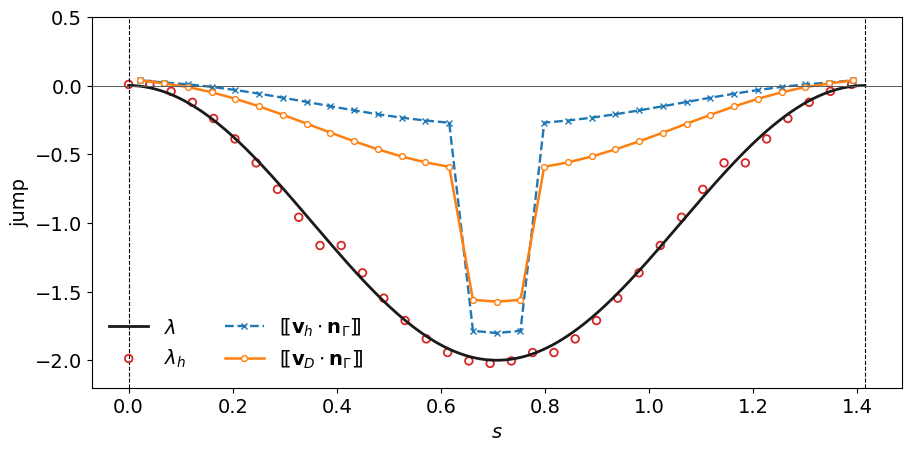

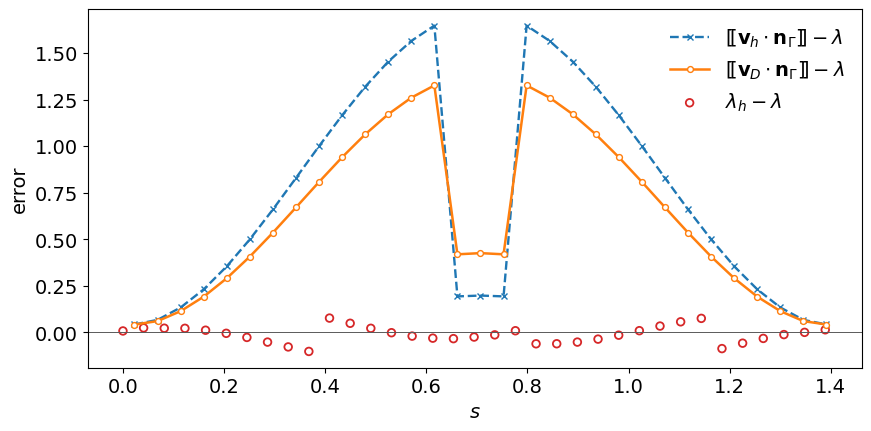

Real fracture jump vs lambda_exact (excluding 5% tips):
  CG    max=1.648e+00  mean=8.267e-01  L2=1.090e+00
  Deng  max=1.327e+00  mean=6.978e-01  L2=8.908e-01
  lam_h max=1.105e-01  mean=3.877e-02  L2=5.267e-02
No ghost extension: the physical fracture spans the full domain diagonal.


/tmp/ipykernel_2969844/2084562640.py:81: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_2969844/2084562640.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
/tmp/ipykernel_2969844/2084562640.py:83: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_r

In [81]:
def cg_jump_on_fracture(ctx, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_cg_numpy(ctx, gdata, x0 + eps * normal[None, :])
    qm = q_cg_numpy(ctx, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


def deng_jump_on_fracture(ctx, local_fluxes, gdata, s_query, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = gdata["real_points_np"](s_query)
    normal = gdata["normal_np"]
    qp = q_rec_numpy(ctx, local_fluxes, gdata, x0 + eps * normal[None, :])
    qm = q_rec_numpy(ctx, local_fluxes, gdata, x0 - eps * normal[None, :])
    return np.sum((qp - qm) * normal[None, :], axis=1)


N_REAL = max(128, 4 * int(ctx_demo.get("n_gamma", 32)))
s_real = np.linspace(0.0, gdata_demo["L_gamma"], N_REAL)
x_real = gdata_demo["real_points_np"](s_real)
lambda_h_real = lambda_h_on_s(ctx_demo, gdata_demo, s_real)
lambda_exact_real = lambda_exact_xy(x_real[:, 0], x_real[:, 1])

# Use P0 multiplier interval midpoints for CG and Deng jump comparison.
s_nodes_jump = np.asarray(ctx_demo.get("lambda_s_nodes", []), dtype=float)
if len(s_nodes_jump) < 2:
    dof_points_jump = ctx_demo["V_l"].tabulate_dof_coordinates()[:, :2]
    s_nodes_jump = np.unique(np.round(np.sort(gdata_demo["s_coord_np"](dof_points_jump)), decimals=14))
s_mid_jump = 0.5 * (s_nodes_jump[:-1] + s_nodes_jump[1:])
x_mid_jump = gdata_demo["real_points_np"](s_mid_jump)
lambda_exact_mid = lambda_exact_xy(x_mid_jump[:, 0], x_mid_jump[:, 1])
jump_cg_mid = cg_jump_on_fracture(ctx_demo, gdata_demo, s_mid_jump)
jump_deng_mid = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_mid_jump)

fig, ax = plt.subplots(figsize=(9.0, 4.4), constrained_layout=True)
ax.plot(s_real, lambda_exact_real, color="0.10", lw=2.0, label=r"$\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], lambda_h_real[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3, label=r"$\lambda_h$")
ax.plot(s_mid_jump, jump_cg_mid, "--", color="tab:blue", lw=1.7, marker="x", ms=4.5,
        markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$")
ax.plot(s_mid_jump, jump_deng_mid, "-", color="tab:orange", lw=1.8, marker="o", ms=4.2,
        mfc="white", markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]$")
ax.axvline(0.0, color="k", ls="--", lw=0.8)
ax.axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel(r"jump")
ax.set_ylim([-2.2,0.5])
ax.grid(False)
ax.legend(frameon=False, ncol=2, handlelength=2.0)
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
ax.plot(s_mid_jump, jump_cg_mid - lambda_exact_mid, "--", color="tab:blue", lw=1.7,
        marker="x", ms=4.5, markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.plot(s_mid_jump, jump_deng_mid - lambda_exact_mid, "-", color="tab:orange", lw=1.8,
        marker="o", ms=4.2, mfc="white", markevery=max(len(s_mid_jump) // 34, 1),
        label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
ax.scatter(s_real[::max(N_REAL // 34, 1)], (lambda_h_real - lambda_exact_real)[::max(N_REAL // 34, 1)],
           s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3,
           label=r"$\lambda_h-\lambda$")
ax.axhline(0.0, color="0.35", lw=0.7)
ax.set_xlabel(r"$s$")
ax.set_ylabel("error")
ax.grid(False)
ax.legend(frameon=False, handlelength=2.0)
plt.show()

mask_mid = (s_mid_jump >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_mid_jump <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
mask_real = (s_real >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_real <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
err_cg_jump = jump_cg_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_deng_jump = jump_deng_mid[mask_mid] - lambda_exact_mid[mask_mid]
err_lh = lambda_h_real[mask_real] - lambda_exact_real[mask_real]
print(f"Real fracture jump vs lambda_exact (excluding {TIP_FRAC*100:.0f}% tips):")
print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapz(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapz(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapz(err_lh**2, s_real[mask_real])):.3e}")

# Ghost-extension jump magnitude. For the full-diagonal MMS this block prints
# that no ghost extension is present.
x_ghost = gdata_demo["ghost_points_np"](n_each=max(64, N_REAL // 2))
if len(x_ghost):
    s_ghost = gdata_demo["s_coord_np"](x_ghost)
    jump_cg_ghost = cg_jump_on_fracture(ctx_demo, gdata_demo, s_ghost)
    jump_deng_ghost = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_ghost)
    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.semilogy(s_ghost, np.abs(jump_cg_ghost) + 1e-30, "--", color="tab:blue", lw=1.7,
                label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.semilogy(s_ghost, np.abs(jump_deng_ghost) + 1e-30, "-", color="tab:orange", lw=1.8,
                label=r"$|[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]|$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("magnitude")
    ax.grid(True, which="both", alpha=0.22)
    ax.legend(frameon=False, handlelength=2.0)
    plt.show()
else:
    print("No ghost extension: the physical fracture spans the full domain diagonal.")


## 3. Residual maps: element-wise and control-volume-wise

### Fracture-segment conservation residual

This evaluates the one-dimensional fracture balance on every fracture-pressure segment `e`:

`R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds`.

The endpoint fluxes are evaluated from the local fracture-pressure element, so shared vertices are not averaged.


In [82]:
# Fracture-segment local conservation residual on Gamma.
# Endpoint fluxes are one-sided values from the current fracture-pressure segment e.

def _fracture_source_values_on_s(s_query):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    pts = real_points_np(s_query)
    vals = np.asarray(f_gamma_exact_xy(pts[:, 0], pts[:, 1]), dtype=float)
    if vals.shape == ():
        vals = np.full(s_query.shape, float(vals), dtype=float)
    return vals.reshape(-1)


def _integrate_fracture_source_segment(s0, s1, nq=12):
    s0 = float(s0)
    s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    if s1 - s0 <= 1.0e-14:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    sq = 0.5 * (s0 + s1) + 0.5 * (s1 - s0) * xi
    return float(0.5 * (s1 - s0) * np.dot(wi, _fracture_source_values_on_s(sq)))


def _integrate_raw_lambda_segment(ctx, s0, s1, nq=12):
    s0 = float(s0)
    s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    if s1 - s0 <= 1.0e-14:
        return 0.0

    # The fracture block assembles +int lambda*psi, so use the RAW solved
    # multiplier. Do not apply lambda_balance_sign, which is only a matrix
    # diagnostic orientation flag.
    if "make_lambda_evaluator" in globals() and "integrate_lambda_s_interval" in globals():
        ctx_raw = dict(ctx)
        ctx_raw["lambda_balance_sign"] = 1.0
        return float(integrate_lambda_s_interval(s0, s1, make_lambda_evaluator(ctx_raw)))

    # Rectangular notebook path: integrate_lambda_interval evaluates the raw multiplier.
    if "integrate_lambda_interval" in globals():
        multiplier_data = _ctx_multiplier_data(ctx) if "_ctx_multiplier_data" in globals() else build_line_space_data(ctx["gamma_l"], ctx["V_l"])
        return float(integrate_lambda_interval(ctx, multiplier_data, s0, s1))

    # Fallback for future copies of this notebook.
    multiplier_data = build_line_space_data(ctx["gamma_l"], ctx["V_l"])
    lvals = np.asarray(ctx["lmbd"].x.array, dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    knots = [s0, s1]
    for cell in multiplier_data["cells"]:
        if s0 < cell["s0"] < s1:
            knots.append(float(cell["s0"]))
        if s0 < cell["s1"] < s1:
            knots.append(float(cell["s1"]))
    knots = np.asarray(sorted(set(np.round(knots, 14))), dtype=float)
    total = 0.0
    for a, b in zip(knots[:-1], knots[1:]):
        if b - a <= 1.0e-14:
            continue
        sq = 0.5 * (a + b) + 0.5 * (b - a) * xi
        vals = np.zeros_like(sq)
        for i, sv in enumerate(sq):
            line_cell = locate_line_cell_s(float(sv), multiplier_data)
            phi = line_values_derivatives_on_cell(line_cell, np.array([sv]))[0][0]
            vals[i] = float(phi @ lvals[line_cell["dofs"]])
        total += 0.5 * (b - a) * float(np.dot(wi, vals))
    return total


def _abs_stats(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return {"n": 0, "mean": np.nan, "max": np.nan}
    abs_values = np.abs(values)
    return {"n": int(values.size), "mean": float(np.mean(abs_values)), "max": float(np.max(abs_values))}


def compute_fracture_segment_residuals(ctx, tip_frac=None, nq_lambda=12, nq_source=12):
    pf_data = build_line_space_data(ctx["gamma"], ctx["V_f"])
    pvals = np.asarray(ctx["p_f"].x.array, dtype=float)
    if tip_frac is None:
        tip_frac = float(globals().get("TIP_FRAC", globals().get("CONV_TIP_FRAC", 0.0)))

    rows = []
    residuals = []
    s_mid = []
    for seg_id, cell in enumerate(pf_data["cells"]):
        s0 = float(cell["s0"])
        s1 = float(cell["s1"])

        # These derivatives use the local element basis on segment e, avoiding
        # the multi-valued shared-vertex flux.
        _, dpsi0 = line_values_derivatives_on_cell(cell, np.array([s0], dtype=float))
        _, dpsi1 = line_values_derivatives_on_cell(cell, np.array([s1], dtype=float))
        q_s0_plus = -K_F_VALUE * float(dpsi0[0] @ pvals[cell["dofs"]])
        q_s1_minus = -K_F_VALUE * float(dpsi1[0] @ pvals[cell["dofs"]])
        flux_boundary = q_s1_minus - q_s0_plus

        lambda_int = _integrate_raw_lambda_segment(ctx, s0, s1, nq=nq_lambda)
        source_int = _integrate_fracture_source_segment(s0, s1, nq=nq_source)
        R_e = flux_boundary + lambda_int - source_int

        residuals.append(R_e)
        mid = 0.5 * (s0 + s1)
        s_mid.append(mid)
        rows.append({
            "segment": int(seg_id),
            "cell": int(cell["cell_id"]),
            "s0": s0,
            "s1": s1,
            "s_mid": mid,
            "q_gamma_s0_plus": q_s0_plus,
            "q_gamma_s1_minus": q_s1_minus,
            "flux_boundary": flux_boundary,
            "lambda_int": lambda_int,
            "source_int": source_int,
            "R_e": R_e,
            "abs_R_e": abs(R_e),
        })

    residuals = np.asarray(residuals, dtype=float)
    s_mid = np.asarray(s_mid, dtype=float)
    L = float(ctx.get("L_gamma", globals().get("L_gamma", s_mid.max() if s_mid.size else 1.0)))
    interior = (s_mid >= tip_frac * L) & (s_mid <= (1.0 - tip_frac) * L)
    all_stats = _abs_stats(residuals)
    interior_stats = _abs_stats(residuals[interior])
    stats = {
        "n_segments": all_stats["n"],
        "mean_abs": all_stats["mean"],
        "max_abs": all_stats["max"],
        "tip_frac": float(tip_frac),
        "n_interior": interior_stats["n"],
        "mean_abs_interior": interior_stats["mean"],
        "max_abs_interior": interior_stats["max"],
    }
    return rows, residuals, stats


fracture_segment_rows, R_gamma_e, fracture_segment_stats = compute_fracture_segment_residuals(ctx_demo)
q0_vals = np.array([r["q_gamma_s0_plus"] for r in fracture_segment_rows], dtype=float)
q1_vals = np.array([r["q_gamma_s1_minus"] for r in fracture_segment_rows], dtype=float)
q_endpoint_vals = np.r_[q0_vals, q1_vals]
flux_boundary_vals = np.array([r["flux_boundary"] for r in fracture_segment_rows], dtype=float)
lambda_int_vals = np.array([r["lambda_int"] for r in fracture_segment_rows], dtype=float)
source_int_vals = np.array([r["source_int"] for r in fracture_segment_rows], dtype=float)
print("Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds")
print("  sign convention: net tangential flux out - int_e f_Gamma ds + int_e lambda_h ds")
print("  flux in R_e is raw CG fracture flux q_Gamma,h = -K_F d_s p_Gamma,h from the local element")
print("  flux values use the local fracture-pressure segment e")
print(f"  q_Gamma,h endpoint min/max = {q_endpoint_vals.min():.6e}, {q_endpoint_vals.max():.6e}")
print(f"  |q_Gamma,h| endpoint mean/max = {np.mean(np.abs(q_endpoint_vals)):.6e}, {np.max(np.abs(q_endpoint_vals)):.6e}")
print(f"  |q_Gamma,h(s1)-q_Gamma,h(s0)| mean/max = {np.mean(np.abs(flux_boundary_vals)):.6e}, {np.max(np.abs(flux_boundary_vals)):.6e}")
print(f"  |int_e f_Gamma ds| mean/max = {np.mean(np.abs(source_int_vals)):.6e}, {np.max(np.abs(source_int_vals)):.6e}")
print(f"  |int_e lambda_h ds| mean/max = {np.mean(np.abs(lambda_int_vals)):.6e}, {np.max(np.abs(lambda_int_vals)):.6e}")
print(f"  segments       = {fracture_segment_stats['n_segments']}")
print(f"  mean |R_e|     = {fracture_segment_stats['mean_abs']:.6e}")
print(f"  max  |R_e|     = {fracture_segment_stats['max_abs']:.6e}")
print(f"  interior count = {fracture_segment_stats['n_interior']}  (excluding {fracture_segment_stats['tip_frac']*100:.0f}% tips)")
print(f"  interior mean  = {fracture_segment_stats['mean_abs_interior']:.6e}")
print(f"  interior max   = {fracture_segment_stats['max_abs_interior']:.6e}")

try:
    import pandas as pd
    fracture_segment_residual_table = pd.DataFrame(fracture_segment_rows)
    display(fracture_segment_residual_table)
except Exception:
    fracture_segment_residual_table = fracture_segment_rows
    print(fracture_segment_rows[:5])


Fracture-segment residual R_e = q_Gamma,e(s1-) - q_Gamma,e(s0+) + int_e lambda_h ds - int_e f_Gamma ds
  sign convention: net tangential flux out - int_e f_Gamma ds + int_e lambda_h ds
  flux in R_e is raw CG fracture flux q_Gamma,h = -K_F d_s p_Gamma,h from the local element
  flux values use the local fracture-pressure segment e
  q_Gamma,h endpoint min/max = -2.221399e+02, 2.221399e+02
  |q_Gamma,h| endpoint mean/max = 1.414270e+02, 2.221399e+02
  |q_Gamma,h(s1)-q_Gamma,h(s0)| mean/max = 0.000000e+00, 0.000000e+00
  |int_e f_Gamma ds| mean/max = 4.876701e+00, 7.667560e+00
  |int_e lambda_h ds| mean/max = 7.855678e-03, 1.572005e-02
  segments       = 182
  mean |R_e|     = 4.881636e+00
  max  |R_e|     = 7.667739e+00
  interior count = 164  (excluding 5% tips)
  interior mean  = 4.589170e+00
  interior max   = 7.667739e+00


,segment,cell,s0,s1,s_mid,q_gamma_s0_plus,q_gamma_s1_minus,flux_boundary,lambda_int,source_int,R_e,abs_R_e
0,0,0,0.000000,0.007770,0.003885,-3.841296,-3.841296,0.0,0.000063,-7.667560,7.667623,7.667623
1,1,1,0.007770,0.015541,0.011656,-11.505115,-11.505115,0.0,0.000063,-7.658431,7.658495,7.658495
2,2,2,0.015541,0.023311,0.019426,-19.155246,-19.155246,0.0,0.000063,-7.640186,7.640249,7.640249
3,3,3,0.023311,0.031082,0.027196,-26.782581,-26.782581,0.0,0.000063,-7.612844,7.612907,7.612907
4,4,4,0.031082,0.038852,0.034967,-34.378039,-34.378039,0.0,0.000063,-7.576440,7.576503,7.576503
...,...,...,...,...,...,...,...,...,...,...,...,...
177,177,177,1.375362,1.383132,1.379247,34.378039,34.378039,0.0,0.000063,-7.576440,7.576503,7.576503
178,178,178,1.383132,1.390902,1.387017,26.782581,26.782581,0.0,0.000063,-7.612844,7.612907,7.612907
179,179,179,1.390902,1.398673,1.394788,19.155246,19.155246,0.0,0.000063,-7.640186,7.640249,7.640249
180,180,180,1.398673,1.406443,1.402558,11.505115,11.505115,0.0,0.000063,-7.658431,7.658495,7.658495


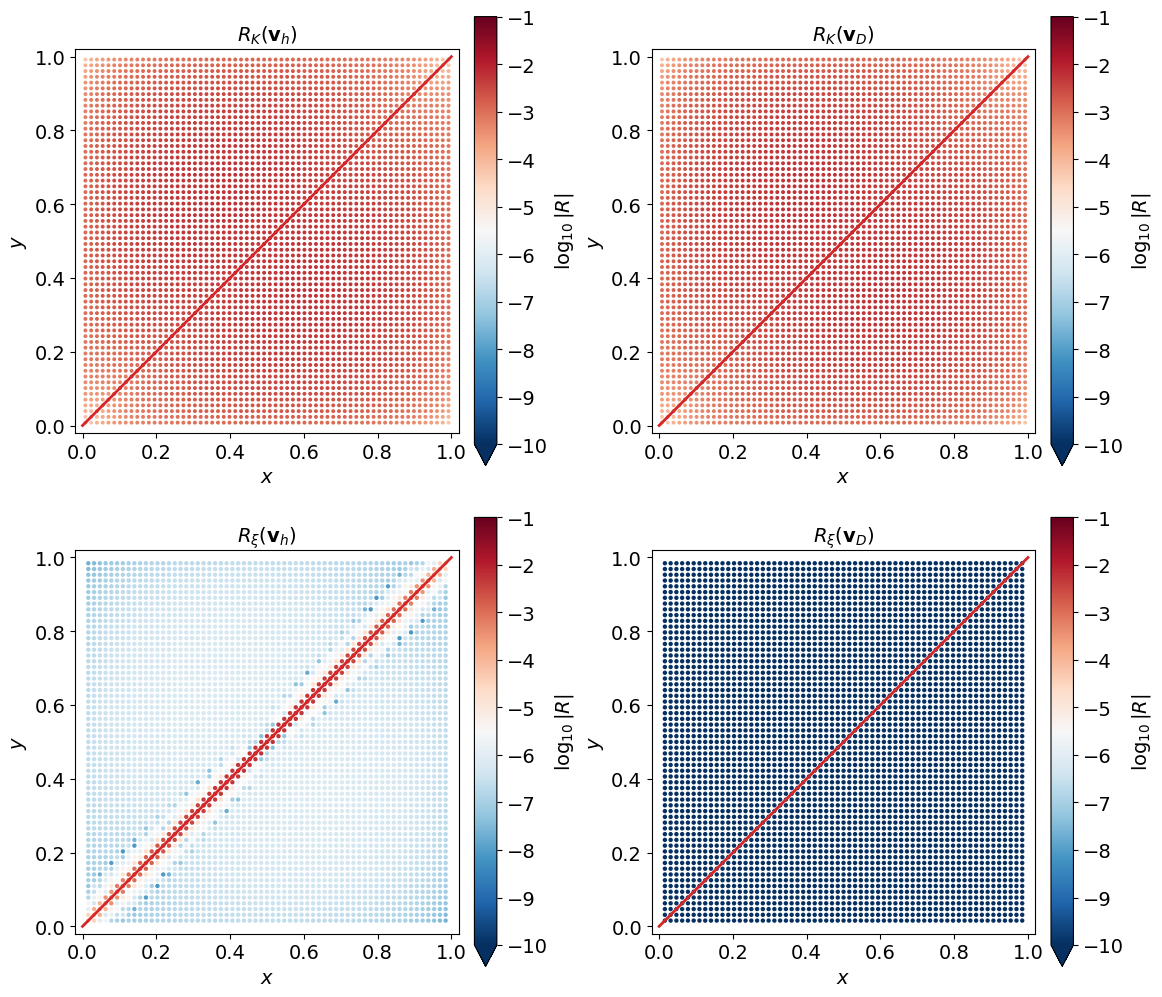

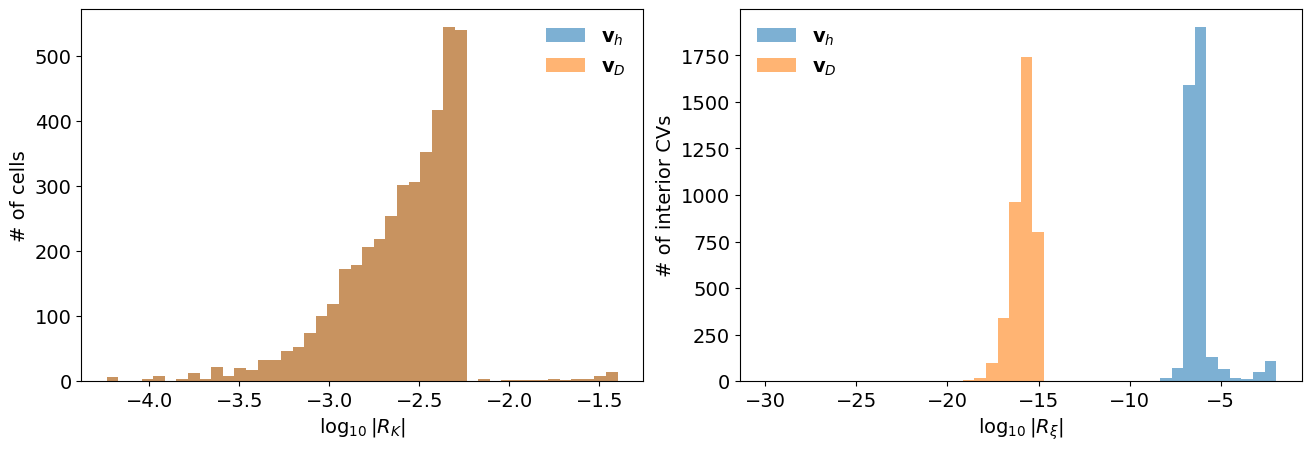

In [83]:
def _log_res(values, eps=1e-30):
    return np.log10(np.abs(values) + eps)


def _map_extend(log_values):
    lo = np.nanmin(log_values)
    hi = np.nanmax(log_values)
    if lo < RK_LOG_VMIN and hi > RK_LOG_VMAX:
        return "both"
    if lo < RK_LOG_VMIN:
        return "min"
    if hi > RK_LOG_VMAX:
        return "max"
    return "neither"


cent = gdata_demo["cell_centroids"]
cv_xy = cv_coords_demo
cv_plot_ids = interior_cv_ids
map_specs = [
    ("Element", r"$R_K(\mathbf{v}_h)$", cent, R_elem_cg),
    ("Element", r"$R_K(\mathbf{v}_D)$", cent, R_elem_rec),
    ("CV", r"$R_\xi(\mathbf{v}_h)$", cv_xy[cv_plot_ids], R_cv_cg[cv_plot_ids]),
    ("CV", r"$R_\xi(\mathbf{v}_D)$", cv_xy[cv_plot_ids], R_cv_rec[cv_plot_ids]),
]
all_logs = np.concatenate([_log_res(vals) for _, _, _, vals in map_specs])
extend = _map_extend(all_logs)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0), constrained_layout=True)
for ax, (kind, title, xy, vals) in zip(axes.ravel(), map_specs):
    sc = ax.scatter(
        xy[:, 0], xy[:, 1], c=_log_res(vals), s=8 if kind == "Element" else 10,
        cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        linewidths=0.0, rasterized=True,
    )
    plot_fracture_lines(ax, gdata_demo)
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.grid(False)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R|$", extend=extend, pad=0.02)
    cbar.set_ticks(RK_CBAR_TICKS)
plt.show()

# Distribution over all matrix cells and all interior CVs.
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
lo_e = min(_log_res(R_elem_cg).min(), _log_res(R_elem_rec).min())
hi_e = max(_log_res(R_elem_cg).max(), _log_res(R_elem_rec).max())
bins_e = np.linspace(lo_e, hi_e, 45)
axes[0].hist(_log_res(R_elem_cg), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[0].hist(_log_res(R_elem_rec), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[0].set_xlabel(r"$\log_{10}|R_K|$")
axes[0].set_ylabel("# of cells")
axes[0].grid(False)
axes[0].legend(frameon=False)

lo_cv = min(_log_res(R_cv_cg[interior_cv_ids]).min(), _log_res(R_cv_rec[interior_cv_ids]).min())
hi_cv = max(_log_res(R_cv_cg[interior_cv_ids]).max(), _log_res(R_cv_rec[interior_cv_ids]).max())
bins_cv = np.linspace(lo_cv, hi_cv, 45)
axes[1].hist(_log_res(R_cv_cg[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
axes[1].hist(_log_res(R_cv_rec[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
axes[1].set_xlabel(r"$\log_{10}|R_\xi|$")
axes[1].set_ylabel("# of interior CVs")
axes[1].grid(False)
axes[1].legend(frameon=False)
plt.show()


## 4. Quantitative comparison table

In [84]:
def print_stats_block(label, before, after, ids_all, ids_focus, focus_label):
    b_all = residual_stats(before, ids_all)
    a_all = residual_stats(after, ids_all)
    b_focus = residual_stats(before, ids_focus)
    a_focus = residual_stats(after, ids_focus)
    imp = improvement_stats(before, after, ids_focus)

    print(label)
    print(f"  all/interior count     = {b_all['n']}")
    print(f"  focus count ({focus_label}) = {b_focus['n']}")
    print(f"  CG    mean={b_all['mean']:.3e} median={b_all['median']:.3e} max={b_all['max']:.3e} | focus mean={b_focus['mean']:.3e} max={b_focus['max']:.3e}")
    print(f"  Deng  mean={a_all['mean']:.3e} median={a_all['median']:.3e} max={a_all['max']:.3e} | focus mean={a_focus['mean']:.3e} max={a_focus['max']:.3e}")
    print(f"  focus improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")
    print()
    return b_all, a_all, b_focus, a_focus, imp


all_cell_ids = np.arange(gdata_demo["num_cells"], dtype=np.int32)
print("Quantitative local-conservation comparison")
print(f"ref={REF_DEMO}, h={ctx_demo['h']:.4e}, total computation time={total_computation_time:.4f} s")
print()
elem_stats = print_stats_block(
    "Element-wise residual R_K",
    R_elem_cg, R_elem_rec, all_cell_ids, frac_cell_ids, "fracture-cut cells"
)
cv_stats = print_stats_block(
    "Control-volume residual R_xi",
    R_cv_cg, R_cv_rec, interior_cv_ids, fracture_cv_ids, "interior fracture-cut CVs"
)


Quantitative local-conservation comparison
ref=6, h=1.5625e-02, total computation time=32.2125 s

Element-wise residual R_K
  all/interior count     = 4096
  focus count (fracture-cut cells) = 64
  CG    mean=3.262e-03 median=2.983e-03 max=3.985e-02 | focus mean=1.991e-02 max=3.985e-02
  Deng  mean=3.262e-03 median=2.983e-03 max=3.985e-02 | focus mean=1.991e-02 max=3.985e-02
  focus improved=0.0% ratio mean=1.000e+00 median=1.000e+00 max=1.000e+00

Control-volume residual R_xi
  all/interior count     = 3969
  focus count (interior fracture-cut CVs) = 63
  CG    mean=1.809e-04 median=4.314e-07 max=1.119e-02 | focus mean=5.678e-03 max=1.119e-02
  Deng  mean=2.771e-16 median=1.800e-16 max=2.552e-15 | focus mean=3.766e-16 max=1.658e-15
  focus improved=100.0% ratio mean=1.111e-13 median=5.316e-14 max=1.760e-12



## 5. Local conservation around the fracture

Fracture-cut cells      : 64
Interior fracture-cut CV dofs: 63


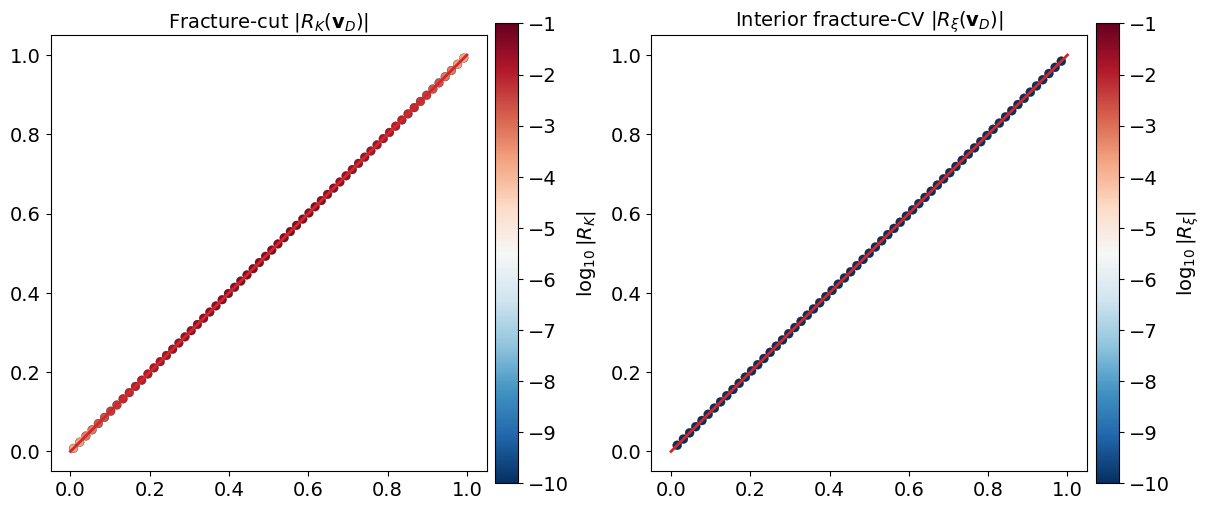

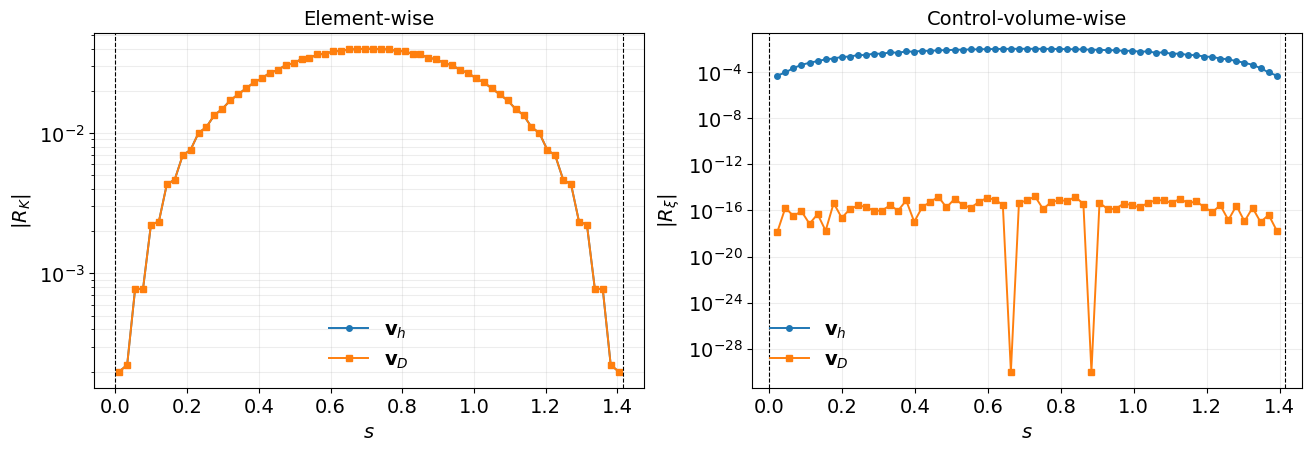


Fracture-cut element residuals (n=64):
  CG    mean=1.991e-02 median=1.986e-02 max=3.985e-02
  Deng  mean=1.991e-02 median=1.986e-02 max=3.985e-02
  improved=0.0% ratio mean=1.000e+00 median=1.000e+00 max=1.000e+00

Interior fracture-cut CV residuals (n=63):
  CG    mean=5.678e-03 median=5.502e-03 max=1.119e-02
  Deng  mean=3.766e-16 median=2.606e-16 max=1.658e-15
  improved=100.0% ratio mean=1.111e-13 median=5.316e-14 max=1.760e-12


In [85]:
cent_frac = gdata_demo["cell_centroids"][frac_cell_ids]
s_elem_frac = gdata_demo["s_coord_np"](cent_frac) if len(frac_cell_ids) else np.array([])
cv_frac_xy = cv_coords_demo[fracture_cv_ids]
s_cv_frac = gdata_demo["s_coord_np"](cv_frac_xy) if len(fracture_cv_ids) else np.array([])

print(f"Fracture-cut cells      : {len(frac_cell_ids)}")
print(f"Interior fracture-cut CV dofs: {len(fracture_cv_ids)}")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), constrained_layout=True)
if len(frac_cell_ids):
    sc0 = axes[0].scatter(
        cent_frac[:, 0], cent_frac[:, 1], c=_log_res(R_elem_rec[frac_cell_ids]),
        s=40, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[0], gdata_demo)
    axes[0].set_title(r"Fracture-cut $|R_K(\mathbf{v}_D)|$")
    axes[0].set_aspect("equal")
    axes[0].grid(False)
    fig.colorbar(sc0, ax=axes[0], label=r"$\log_{10}|R_K|$", pad=0.02)
else:
    axes[0].set_title("No fracture-cut cells")

if len(fracture_cv_ids):
    sc1 = axes[1].scatter(
        cv_frac_xy[:, 0], cv_frac_xy[:, 1], c=_log_res(R_cv_rec[fracture_cv_ids]),
        s=42, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
        edgecolors="k", linewidths=0.2, rasterized=True,
    )
    plot_fracture_lines(axes[1], gdata_demo)
    axes[1].set_title(r"Interior fracture-CV $|R_\xi(\mathbf{v}_D)|$")
    axes[1].set_aspect("equal")
    axes[1].grid(False)
    fig.colorbar(sc1, ax=axes[1], label=r"$\log_{10}|R_\xi|$", pad=0.02)
else:
    axes[1].set_title("No interior fracture CVs")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
if len(frac_cell_ids):
    idx = np.argsort(s_elem_frac)
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[0].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[0].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[0].set_xlabel(r"$s$")
    axes[0].set_ylabel(r"$|R_K|$")
    axes[0].set_title("Element-wise")
    axes[0].grid(True, which="both", alpha=0.22)
    axes[0].legend(frameon=False)

if len(fracture_cv_ids):
    idx = np.argsort(s_cv_frac)
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_cg[fracture_cv_ids][idx]) + 1e-30,
                     "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
    axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_rec[fracture_cv_ids][idx]) + 1e-30,
                     "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
    axes[1].axvline(0.0, color="k", ls="--", lw=0.8)
    axes[1].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    axes[1].set_xlabel(r"$s$")
    axes[1].set_ylabel(r"$|R_\xi|$")
    axes[1].set_title("Control-volume-wise")
    axes[1].grid(True, which="both", alpha=0.22)
    axes[1].legend(frameon=False)
plt.show()

for label, before, after, ids in [
    ("Fracture-cut element residuals", R_elem_cg, R_elem_rec, frac_cell_ids),
    ("Interior fracture-cut CV residuals", R_cv_cg, R_cv_rec, fracture_cv_ids),
]:
    b = residual_stats(before, ids)
    a = residual_stats(after, ids)
    imp = improvement_stats(before, after, ids)
    print(f"\n{label} (n={b['n']}):")
    print(f"  CG    mean={b['mean']:.3e} median={b['median']:.3e} max={b['max']:.3e}")
    print(f"  Deng  mean={a['mean']:.3e} median={a['median']:.3e} max={a['max']:.3e}")
    print(f"  improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")
